# Phân tích ICOR Việt Nam 1990-2024

## Mục tiêu
-	Mô tả xu hướng biến động ICOR qua từng giai đoạn kinh tế.
-	Chẩn đoán nguyên nhân gây biến động bất thường bằng kiểm định thống kê.
-	So sánh hiệu quả đầu tư của Việt Nam với các quốc gia trong khu vực.
-	Dự báo ICOR cho 5 năm tới (2025–2029) bằng mô hình ARIMAX.



In [3]:
# Cấu hình thư viện và hàm dùng chung
from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", ConvergenceWarning)
plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

# Chạy notebook từ đúng thư mục dự án để tránh lỗi đường dẫn có dấu tiếng Việt.
BASE_DIR = Path.cwd()
START_YEAR = 1990
END_YEAR = 2024


def read_wb_csv(path: Path) -> pd.DataFrame | None:
    """Đọc CSV World Bank, bỏ 4 dòng metadata đầu."""
    if not path.exists():
        print(f"Thiếu tệp: {path}")
        return None
    try:
        df = pd.read_csv(path, skiprows=4)
        print(f"Đọc {path.name}: {df.shape}")
        return df
    except Exception as exc:
        print(f"Không đọc được {path}: {exc}")
        return None


def to_long_country(df: pd.DataFrame, value_name: str, country: str | None = None) -> pd.DataFrame:
    """Chuyển dữ liệu World Bank từ wide sang long; có thể lọc theo quốc gia."""
    if df is None:
        return pd.DataFrame(columns=["Country Name", "year", value_name])

    data = df.copy()
    if country is not None:
        mask = data["Country Name"].str.casefold().eq(country.casefold())
        data = data.loc[mask].copy()

    id_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
    year_cols = [col for col in data.columns if str(col).isdigit()]
    long_df = data[id_cols + year_cols].melt(
        id_vars=id_cols,
        var_name="year",
        value_name=value_name,
    )
    long_df["year"] = long_df["year"].astype(int)
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df


def merge_country_indicators(raw_data: dict[str, pd.DataFrame], country: str) -> pd.DataFrame:
    """Lấy một quốc gia cho tất cả chỉ tiêu và merge theo năm."""
    merged_df = None
    for key, raw_df in raw_data.items():
        long_df = to_long_country(raw_df, key, country)
        use_cols = long_df[["year", key]].copy()
        merged_df = use_cols if merged_df is None else merged_df.merge(use_cols, on="year", how="outer")
        print(f"{key}: {use_cols.shape}")

    value_cols = [col for col in merged_df.columns if col != "year"]
    merged_df[value_cols] = merged_df[value_cols].apply(pd.to_numeric, errors="coerce")
    return merged_df.sort_values("year").reset_index(drop=True)


def interpolate_and_filter_years(data: pd.DataFrame, start_year: int, end_year: int) -> pd.DataFrame:
    """Nội suy tuyến tính và giữ giai đoạn nghiên cứu."""
    out = data.copy().set_index("year")
    out = out.interpolate(method="linear", limit_direction="both").reset_index()
    return out.loc[out["year"].between(start_year, end_year)].reset_index(drop=True)


def add_icor(data: pd.DataFrame) -> pd.DataFrame:
    """Tính ICOR hiện tại và ICOR trễ từ chuỗi gốc."""
    required = {"gcf", "gdp_growth"}
    missing = required.difference(data.columns)
    if missing:
        raise ValueError(f"Thiếu cột để tính ICOR: {sorted(missing)}")

    out = data.copy()
    out["icor"] = out["gcf"] / out["gdp_growth"]
    out["icor_lag"] = out["gcf"].shift(1) / out["gdp_growth"]
    return out


def detect_diff_outliers(data: pd.DataFrame, columns: list[str], threshold: float = 2.0) -> dict[str, list[int]]:
    """Phát hiện năm biến động mạnh bằng sai phân bậc 1 và ngưỡng độ lệch chuẩn."""
    result = {}
    diff_df = data[["year"] + columns].copy()
    for col in columns:
        diff_df[col] = diff_df[col].diff()
        s = diff_df[col].dropna()
        lower = s.mean() - threshold * s.std()
        upper = s.mean() + threshold * s.std()
        years = diff_df.loc[(diff_df[col] < lower) | (diff_df[col] > upper), "year"].astype(int).tolist()
        result[col] = years
    return result


def get_country_icor(raw_data: dict[str, pd.DataFrame], countries: list[str], start_year: int, end_year: int) -> pd.DataFrame:
    """Tính ICOR gốc cho nhiều quốc gia."""
    gcf_long = to_long_country(raw_data["gcf"], "gcf")
    gdp_long = to_long_country(raw_data["gdp_growth"], "gdp_growth")
    region = gcf_long[gcf_long["Country Name"].isin(countries)][["Country Name", "year", "gcf"]]
    region = region.merge(
        gdp_long[gdp_long["Country Name"].isin(countries)][["Country Name", "year", "gdp_growth"]],
        on=["Country Name", "year"],
        how="inner",
    )
    region = region.loc[region["year"].between(start_year, end_year)].copy()
    region["icor"] = region["gcf"] / region["gdp_growth"]
    return region


## 1. Đọc dữ liệu CSV và hợp nhất theo năm

Đọc các chỉ tiêu World Bank: GCF, tăng trưởng GDP, FDI, thương mại, lãi suất cho vay và M2. Dữ liệu được chuẩn hóa từ dạng wide sang long trước khi hợp nhất theo năm.


In [4]:
file_map = {
    "gcf": BASE_DIR / "GCF" / "API_NE.GDI.TOTL.ZS_DS2_en_csv_v2_115698.csv",
    "gdp_growth": BASE_DIR / "GDP" / "API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_121708.csv",
    "fdi": BASE_DIR / "FDI" / "API_BX.KLT.DINV.WD.GD.ZS_DS2_en_csv_v2_115540.csv",
    "trade": BASE_DIR / "Trade" / "API_NE.TRD.GNFS.ZS_DS2_en_csv_v2_115680.csv",
    "lir": BASE_DIR / "LIR" / "API_FR.INR.LEND_DS2_en_csv_v2_3268.csv",
    "m2": BASE_DIR / "BM" / "API_FM.LBL.BMNY.GD.ZS_DS2_en_csv_v2_5797.csv",
}

print("Kiểm tra tệp dữ liệu:")
for key, path in file_map.items():
    print(f"{key:>10}: {'OK' if path.exists() else 'THIẾU'} - {path.name}")

print("\nĐọc dữ liệu:")
raw = {key: read_wb_csv(path) for key, path in file_map.items()}

print("\nKích thước dữ liệu thô:")
for key, data in raw.items():
    print(f"{key:>10}: {None if data is None else data.shape}")


Kiểm tra tệp dữ liệu:
       gcf: OK - API_NE.GDI.TOTL.ZS_DS2_en_csv_v2_115698.csv
gdp_growth: OK - API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_121708.csv
       fdi: OK - API_BX.KLT.DINV.WD.GD.ZS_DS2_en_csv_v2_115540.csv
     trade: OK - API_NE.TRD.GNFS.ZS_DS2_en_csv_v2_115680.csv
       lir: OK - API_FR.INR.LEND_DS2_en_csv_v2_3268.csv
        m2: OK - API_FM.LBL.BMNY.GD.ZS_DS2_en_csv_v2_5797.csv

Đọc dữ liệu:
Đọc API_NE.GDI.TOTL.ZS_DS2_en_csv_v2_115698.csv: (266, 71)
Đọc API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_121708.csv: (266, 71)
Đọc API_BX.KLT.DINV.WD.GD.ZS_DS2_en_csv_v2_115540.csv: (266, 71)
Đọc API_NE.TRD.GNFS.ZS_DS2_en_csv_v2_115680.csv: (266, 71)
Đọc API_FR.INR.LEND_DS2_en_csv_v2_3268.csv: (266, 71)
Đọc API_FM.LBL.BMNY.GD.ZS_DS2_en_csv_v2_5797.csv: (266, 71)

Kích thước dữ liệu thô:
       gcf: (266, 71)
gdp_growth: (266, 71)
       fdi: (266, 71)
     trade: (266, 71)
       lir: (266, 71)
        m2: (266, 71)


## 2. Lọc Việt Nam, làm sạch kiểu dữ liệu và xử lý thiếu

Dữ liệu Việt Nam được lọc theo `Country Name = Viet Nam`, ép kiểu số, nội suy tuyến tính các điểm thiếu và giữ giai đoạn 1990-2024.


In [5]:
print("Hợp nhất dữ liệu Việt Nam:")
merged = merge_country_indicators(raw, "Viet Nam")

print(f"\nDữ liệu trước nội suy: {merged.shape}")
print(merged.head(10))


Hợp nhất dữ liệu Việt Nam:
gcf: (66, 2)
gdp_growth: (66, 2)
fdi: (66, 2)
trade: (66, 2)
lir: (66, 2)
m2: (66, 2)

Dữ liệu trước nội suy: (66, 7)
   year  gcf  gdp_growth  fdi  trade  lir  m2
0  1960  NaN         NaN  NaN    NaN  NaN NaN
1  1961  NaN         NaN  NaN    NaN  NaN NaN
2  1962  NaN         NaN  NaN    NaN  NaN NaN
3  1963  NaN         NaN  NaN    NaN  NaN NaN
4  1964  NaN         NaN  NaN    NaN  NaN NaN
5  1965  NaN         NaN  NaN    NaN  NaN NaN
6  1966  NaN         NaN  NaN    NaN  NaN NaN
7  1967  NaN         NaN  NaN    NaN  NaN NaN
8  1968  NaN         NaN  NaN    NaN  NaN NaN
9  1969  NaN         NaN  NaN    NaN  NaN NaN


In [6]:
print("Giá trị thiếu trước nội suy:")
print(merged.isna().sum())

merged_interp = interpolate_and_filter_years(merged, START_YEAR, END_YEAR)

print("\nGiá trị thiếu sau nội suy và lọc năm:")
print(merged_interp.isna().sum().sort_values(ascending=False))

min_year = int(merged_interp["year"].min())
max_year = int(merged_interp["year"].max())
print(f"\nDải năm phân tích: {min_year}-{max_year}; số quan sát: {len(merged_interp)}")
if max_year < END_YEAR:
    print(f"Nguồn hiện chỉ có đến {max_year}, chưa có {END_YEAR}.")

print(merged_interp.head(10))


Giá trị thiếu trước nội suy:
year           0
gcf           36
gdp_growth    26
fdi           26
trade         27
lir           37
m2            36
dtype: int64

Giá trị thiếu sau nội suy và lọc năm:
year          0
gcf           0
gdp_growth    0
fdi           0
trade         0
lir           0
m2            0
dtype: int64

Dải năm phân tích: 1990-2024; số quan sát: 35
   year        gcf  gdp_growth        fdi       trade        lir         m2
0  1990  27.144243    5.100918   2.781323   81.315698  32.182500  22.507528
1  1991  27.144243    5.960844   3.902797   66.946952  32.182500  22.507528
2  1992  27.144243    8.646047   4.803348   73.576885  32.182500  22.507528
3  1993  27.144243    8.072731   7.027593   66.212267  32.182500  20.074554
4  1994  27.144243    8.838981  11.939483   77.473198  28.155000  19.820522
5  1995  27.144243    9.540480   8.585966   74.721266  24.127500  19.566489
6  1996  28.102898    9.340017   9.713081   92.705747  20.100000  20.710062
7  1997  28.299583  

## 3. Kiểm tra ngoại lệ và trực quan hóa dữ liệu thô

Dùng IQR/z-score để phát hiện ngoại lệ; vẽ line plot để rà soát


Năm biến động mạnh theo sai phân bậc 1 (ngưỡng ±2 độ lệch chuẩn):
       GCF: [2007, 2011]
GDP_GROWTH: [2020, 2022, 2023]


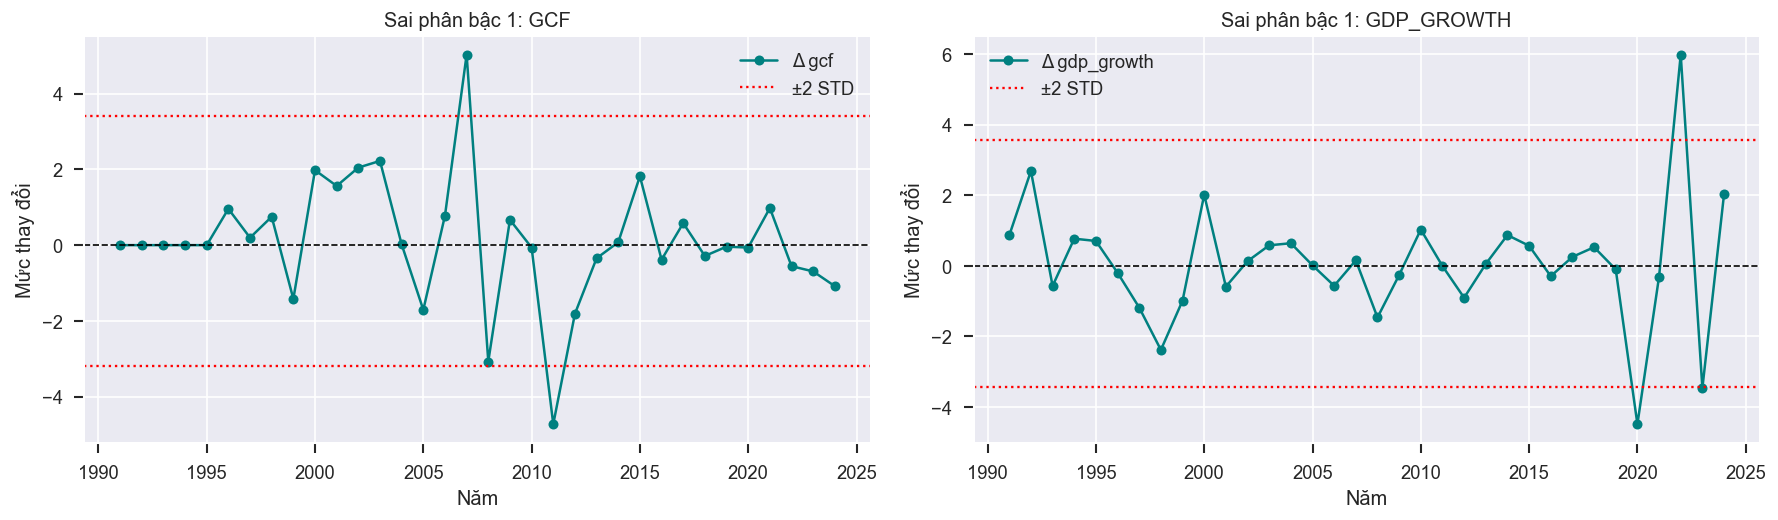

In [7]:
diff_cols = [col for col in ["gcf", "gdp_growth"] if col in merged_interp.columns]
if not diff_cols:
    raise ValueError("Không có cột GCF hoặc GDP growth để kiểm tra biến động.")

outlier_by_diff = detect_diff_outliers(merged_interp, diff_cols, threshold=2.0)
merged_diff = merged_interp[["year"] + diff_cols].copy()
for col in diff_cols:
    merged_diff[col] = merged_diff[col].diff()

fig, axes = plt.subplots(1, len(diff_cols), figsize=(7.5 * len(diff_cols), 4.5), squeeze=False)
axes = axes.ravel()

print("Năm biến động mạnh theo sai phân bậc 1 (ngưỡng ±2 độ lệch chuẩn):")
for ax, col in zip(axes, diff_cols):
    s = merged_diff[col].dropna()
    lower = s.mean() - 2 * s.std()
    upper = s.mean() + 2 * s.std()

    ax.plot(merged_diff["year"], merged_diff[col], marker="o", color="teal", label=f"Δ {col}")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(upper, color="red", linestyle=":", linewidth=1.4, label="±2 STD")
    ax.axhline(lower, color="red", linestyle=":", linewidth=1.4)
    ax.set_title(f"Sai phân bậc 1: {col.upper()}")
    ax.set_xlabel("Năm")
    ax.set_ylabel("Mức thay đổi")
    ax.legend(loc="best")

    years = outlier_by_diff[col]
    print(f"{col.upper():>10}: {years if years else '(không có)'}")

plt.tight_layout()
plt.show()


**Nhận xét**

- GCF có biến động mạnh ở 2007 và 2011. Đây là hai điểm cần chú ý vì trùng với giai đoạn sau khi Việt Nam gia nhập WTO và giai đoạn thắt chặt vĩ mô sau lạm phát cao.
- GDP growth biến động mạnh ở 2020, 2022 và 2023. Mẫu hình này phù hợp với cú sốc COVID-19, phục hồi mạnh năm 2022 rồi giảm tốc năm 2023.
- Kết quả trên chỉ phản ánh năm có mức thay đổi lớn của chuỗi gốc; chưa nên xem đây là bằng chứng nhân quả.


## 4. Tính ICOR cơ bản và ICOR trễ (KHÔNG smoothing)

- ICOR$_t$ = GCF$_t$ / GDPgrowth$_t$
- ICOR$_{t,lag}$ = GCF$_{t-1}$ / GDPgrowth$_t$

Lưu ý: **TUYỆT ĐỐI KHÔNG** dùng moving average / rolling mean / smoothing.

In [8]:
df = add_icor(merged_interp)

print("Đã tính ICOR từ chuỗi gốc, không smoothing.")
print(df[["year", "gcf", "gdp_growth", "icor", "icor_lag"]].head(10))


Đã tính ICOR từ chuỗi gốc, không smoothing.
   year        gcf  gdp_growth      icor  icor_lag
0  1990  27.144243    5.100918  5.321443       NaN
1  1991  27.144243    5.960844  4.553758  4.553758
2  1992  27.144243    8.646047  3.139497  3.139497
3  1993  27.144243    8.072731  3.362461  3.362461
4  1994  27.144243    8.838981  3.070970  3.070970
5  1995  27.144243    9.540480  2.845165  2.845165
6  1996  28.102898    9.340017  3.008870  2.906230
7  1997  28.299583    8.152084  3.471454  3.447327
8  1998  29.049879    5.764455  5.039484  4.909325
9  1999  27.629756    4.773587  5.788049  6.085545


## 5. Endogenous Break Detection: tự động tìm 3 điểm gãy và chia 4 giai đoạn

Để chia chuỗi thời gian thành 4 giai đoạn một cách thuần túy, cần 3 điểm gãy cấu trúc. Phần này không gán trước các mốc lịch sử như 2008 hay 2020, mà dùng Grid Search Chow Test / QLR Test để quét các năm ứng viên dựa hoàn toàn vào thuộc tính toán học của chuỗi ICOR.

Thuật toán bỏ 5 năm đầu và 5 năm cuối nhằm đảm bảo mỗi phân đoạn có kích thước mẫu tối thiểu. Sau đó chọn Top 3 năm có F-statistic cao nhất, ưu tiên các điểm có p-value nhỏ hơn 0.05. Ba điểm gãy này được dùng để tự động chia chuỗi thành 4 giai đoạn liên tiếp, tính thống kê mô tả và vẽ biểu đồ với nhãn `Auto Break [Năm]`.


Top 10 điểm gãy ứng viên theo F-statistic:
 break_year  f_stat  p_value  n_left  n_right
       2019  8.8799   0.0054      29        6
       1998  7.4922   0.0099       8       27
       1999  6.9325   0.0128       9       26
       2007  6.5092   0.0156      17       18
       2018  6.3886   0.0165      28        7
       2006  6.3463   0.0168      16       19
       2001  6.1517   0.0184      11       24
       2008  6.0616   0.0192      18       17
       2002  5.9546   0.0202      12       23
       1997  5.9390   0.0204       7       28

Top 3 Auto Break Years: [1998, 1999, 2019]

Bảng thống kê mô tả theo 4 giai đoạn tự động:
Giai đoạn  Từ năm  Đến năm  Số năm  icor_mean  icor_std  gcf_mean  gcf_std  gdp_growth_mean  gdp_growth_std
1990-1997    1990     1997       8      3.597     0.818    27.408    0.460            7.957           1.494
1998-1998    1998     1998       1      5.039     0.000    29.050    0.000            5.764           0.000
1999-2018    1999     2018      20  

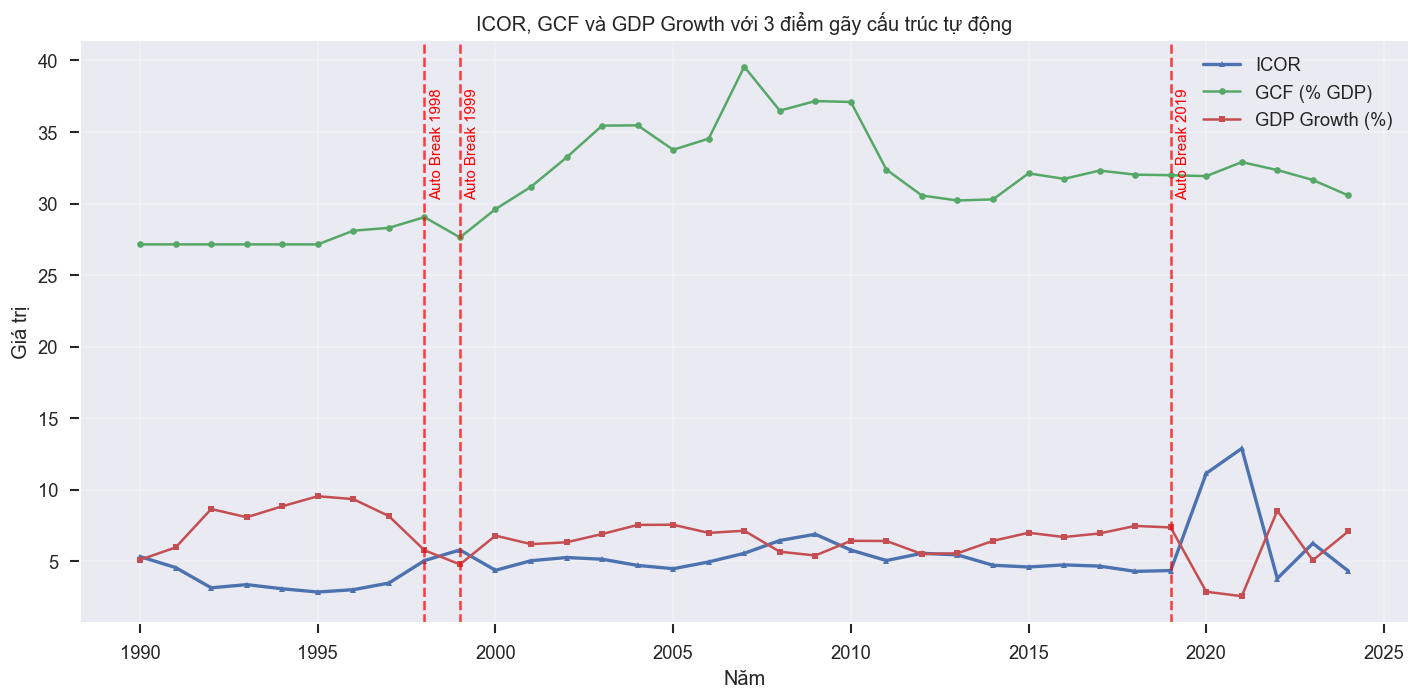

In [9]:
def chow_test_at_break(data: pd.DataFrame, break_year: int, y_col: str = "icor") -> dict:
    """Tính Chow Test tại một năm gãy ứng viên.

    Mô hình nền: ICOR ~ hằng số. Cách này kiểm định thay đổi mức
    trung bình của ICOR giữa hai phân đoạn trước/sau điểm gãy.
    """
    clean = (
        data[["year", y_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values("year")
        .reset_index(drop=True)
    )

    y = clean[y_col].to_numpy(dtype=float)
    years = clean["year"].astype(int).to_numpy()
    X = np.ones((len(clean), 1))

    split_idx = int(np.searchsorted(years, break_year, side="left"))
    y_left, X_left = y[:split_idx], X[:split_idx]
    y_right, X_right = y[split_idx:], X[split_idx:]

    k = X.shape[1]
    n = len(y)
    if len(y_left) <= k or len(y_right) <= k or n <= 2 * k:
        return {
            "break_year": int(break_year),
            "f_stat": np.nan,
            "p_value": np.nan,
            "n_left": len(y_left),
            "n_right": len(y_right),
        }

    rss_full = sm.OLS(y, X).fit().ssr
    rss_left = sm.OLS(y_left, X_left).fit().ssr
    rss_right = sm.OLS(y_right, X_right).fit().ssr

    numerator = (rss_full - (rss_left + rss_right)) / k
    denominator = (rss_left + rss_right) / (n - 2 * k)
    f_stat = numerator / denominator
    p_value = stats.f.sf(f_stat, k, n - 2 * k)

    return {
        "break_year": int(break_year),
        "f_stat": float(f_stat),
        "p_value": float(p_value),
        "n_left": len(y_left),
        "n_right": len(y_right),
    }


def grid_search_chow_breaks(data: pd.DataFrame, y_col: str = "icor", trim: int = 5, top_n: int = 3) -> tuple[pd.DataFrame, list[int]]:
    """Quét toàn bộ chuỗi để tìm các điểm gãy nội sinh bằng Chow/QLR Test."""
    clean = (
        data[["year", y_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values("year")
        .reset_index(drop=True)
    )
    if len(clean) <= 2 * trim + top_n:
        raise ValueError("Chuỗi quá ngắn để quét 3 điểm gãy với trim hiện tại.")

    candidate_years = clean["year"].astype(int).iloc[trim:-trim].tolist()
    results = pd.DataFrame(chow_test_at_break(data, year, y_col) for year in candidate_years)
    results = results.dropna(subset=["f_stat", "p_value"]).sort_values("f_stat", ascending=False).reset_index(drop=True)

    significant = results.loc[results["p_value"] < 0.05].copy()
    if len(significant) >= top_n:
        selected_years = significant.head(top_n)["break_year"].astype(int).tolist()
    else:
        selected_years = results.head(top_n)["break_year"].astype(int).tolist()
        print("Cảnh báo: Không đủ 3 điểm gãy có p-value < 0.05; dùng Top F-statistic để tham khảo.")

    return results, sorted(selected_years)


def build_four_periods_from_three_breaks(data: pd.DataFrame, break_years: list[int]) -> dict[str, tuple[int, int]]:
    """Tạo đúng 4 giai đoạn liên tiếp từ 3 điểm gãy tự động."""
    if len(break_years) != 3:
        raise ValueError("Cần đúng 3 điểm gãy để chia chuỗi thành 4 giai đoạn.")

    start_year = int(data["year"].min())
    end_year = int(data["year"].max())
    b1, b2, b3 = sorted(map(int, break_years))

    raw_periods = [
        (f"{start_year}-{b1 - 1}", start_year, b1 - 1),
        (f"{b1}-{b2 - 1}", b1, b2 - 1),
        (f"{b2}-{b3 - 1}", b2, b3 - 1),
        (f"{b3}-{end_year}", b3, end_year),
    ]

    periods = {
        label: (start, end)
        for label, start, end in raw_periods
        if start <= end and data["year"].between(start, end).any()
    }
    if len(periods) != 4:
        raise ValueError("Ba điểm gãy quá sát nhau hoặc sát biên nên không tạo đủ 4 giai đoạn hợp lệ.")
    return periods


def describe_periods(data: pd.DataFrame, periods: dict[str, tuple[int, int]], value_cols: list[str]) -> pd.DataFrame:
    """Tính Mean, Std và số năm cho từng biến trong từng giai đoạn."""
    rows = []
    for period_name, (start, end) in periods.items():
        sub = data.loc[data["year"].between(start, end), ["year"] + value_cols].replace([np.inf, -np.inf], np.nan)
        row = {
            "Giai đoạn": period_name,
            "Từ năm": start,
            "Đến năm": end,
            "Số năm": int(sub["year"].nunique()),
        }
        for col in value_cols:
            row[f"{col}_mean"] = sub[col].mean()
            row[f"{col}_std"] = sub[col].std(ddof=0)
        rows.append(row)
    return pd.DataFrame(rows)


# 1. Grid Search Chow Test / QLR Test: tìm 3 điểm gãy nội sinh từ chuỗi ICOR
break_scan_df, auto_break_years = grid_search_chow_breaks(df, y_col="icor", trim=5, top_n=3)

print("Top 10 điểm gãy ứng viên theo F-statistic:")
print(break_scan_df.head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nTop 3 Auto Break Years: {auto_break_years}")

# 2. Tự động chia 4 giai đoạn từ 3 điểm gãy và tính thống kê mô tả
periods = build_four_periods_from_three_breaks(df, auto_break_years)
summary_df = describe_periods(df, periods, value_cols=["icor", "gcf", "gdp_growth"])

print("\nBảng thống kê mô tả theo 4 giai đoạn tự động:")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 3. Trực quan hóa 3 chuỗi và đánh dấu điểm gãy tự động
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["year"], df["icor"], label="ICOR", marker="^", markersize=4, linewidth=2)
ax.plot(df["year"], df["gcf"], label="GCF (% GDP)", marker="o", markersize=4)
ax.plot(df["year"], df["gdp_growth"], label="GDP Growth (%)", marker="s", markersize=4)

upper_y = ax.get_ylim()[1]
for break_year in auto_break_years:
    ax.axvline(break_year, color="red", linestyle="--", alpha=0.75, linewidth=1.5)
    ax.text(
        break_year + 0.15,
        upper_y * 0.92,
        f"Auto Break {break_year}",
        color="red",
        fontsize=9,
        rotation=90,
        va="top",
    )

ax.set_title("ICOR, GCF và GDP Growth với 3 điểm gãy cấu trúc tự động")
ax.set_xlabel("Năm")
ax.set_ylabel("Giá trị")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


**Nhận xét và đánh giá giai đoạn**

Các mốc `1998`, `1999` và `2019` được chọn bởi thuật toán Grid Search Chow/QLR dựa trên F-statistic của chuỗi ICOR, không phải do áp đặt trước từ bối cảnh lịch sử. Vì vậy, phần lịch sử dưới đây chỉ dùng để diễn giải thêm sau khi điểm gãy đã được dữ liệu xác định.

- **1990-1997:** ICOR trung bình khoảng 3.60, thấp nhất trong 4 giai đoạn; GDP growth trung bình gần 7.96%. Đây là giai đoạn Việt Nam tăng trưởng nhanh sau Đổi mới, mở rộng sản xuất và thu hút vốn đầu tư ban đầu. ICOR thấp cho thấy mỗi đơn vị vốn tạo ra tăng trưởng tương đối hiệu quả.

- **1998:** ICOR tăng lên khoảng 5.04, cao hơn rõ so với giai đoạn trước. Đây là năm chịu tác động lan tỏa từ khủng hoảng tài chính châu Á 1997-1998, khiến tăng trưởng GDP giảm tốc. Tuy nhiên, vì giai đoạn này chỉ có 1 năm nên không nên kết luận như một xu hướng dài hạn; nên xem đây là điểm chuyển tiếp/cú sốc ngắn hạn.

- **1999-2018:** ICOR trung bình khoảng 5.17, cao hơn giai đoạn 1990-1997; GCF trung bình cũng tăng lên khoảng 33.14% GDP. Giai đoạn này phản ánh quá trình công nghiệp hóa, đô thị hóa, mở rộng đầu tư công và hội nhập sâu hơn, đặc biệt quanh thời điểm gia nhập WTO năm 2007. ICOR cao hơn cho thấy tăng trưởng phụ thuộc nhiều hơn vào vốn, trong khi hiệu quả vốn không còn tốt như giai đoạn đầu Đổi mới.

- **2019-2024:** ICOR trung bình khoảng 7.12 và độ lệch chuẩn cao nhất, cho thấy hiệu quả vốn biến động mạnh. Về lịch sử, giai đoạn này bao gồm cú sốc COVID-19 2020-2021, phục hồi mạnh năm 2022 và giảm tốc do tổng cầu thế giới yếu hơn sau đó. ICOR tăng mạnh chủ yếu vì GDP growth giảm/dao động, không nhất thiết vì đầu tư tăng đột biến.

Tóm lại, kết quả tự động khá hợp lý khi tách được: giai đoạn tăng trưởng hiệu quả cao ban đầu, cú sốc chuyển tiếp 1998, giai đoạn tăng trưởng dựa nhiều hơn vào vốn 1999-2018, và giai đoạn biến động mạnh sau 2019. Cách đọc phù hợp là: dữ liệu xác định điểm gãy, còn bối cảnh lịch sử giúp giải thích vì sao các điểm gãy đó có ý nghĩa kinh tế.


## 6. EDA: Xu hướng, năm bất thường và chia giai đoạn

Phân tích xu hướng, xác định năm bất thường bằng z-score và chú thích sự kiện


Năm ICOR bất thường (|z-score| > 2.5): [2020, 2021]


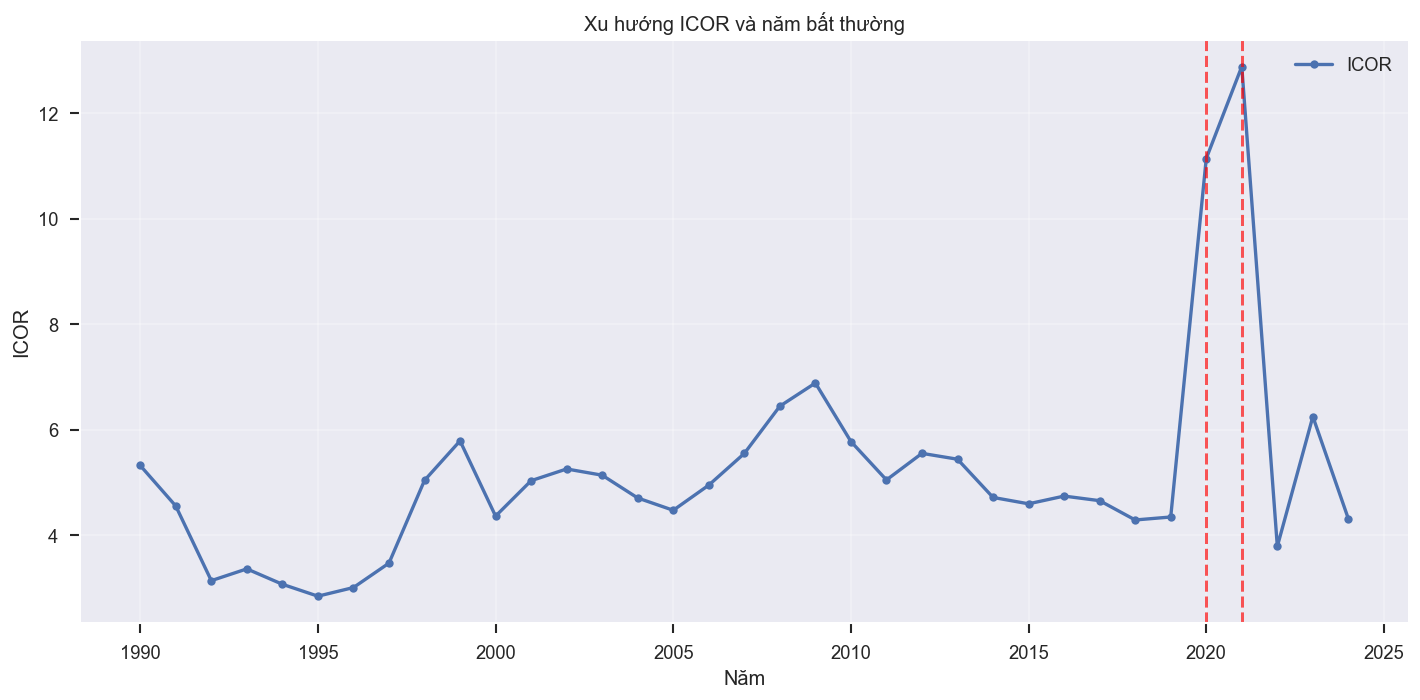

Thống kê ICOR:
Trung bình: 5.1407
Độ lệch chuẩn: 1.9823
Min: 2.8452
Năm min: 1995
Max: 12.8814
Năm max: 2021


In [10]:
icor_series = df.set_index("year")["icor"].dropna()
z_score = (icor_series - icor_series.mean()) / icor_series.std(ddof=0)
icor_outlier_years = z_score.index[z_score.abs() > 2.5].astype(int).tolist()

print(f"Năm ICOR bất thường (|z-score| > 2.5): {icor_outlier_years if icor_outlier_years else '(không có)'}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(icor_series.index, icor_series.values, label="ICOR", marker="o", markersize=5, linewidth=2)
for year in icor_outlier_years:
    ax.axvline(year, color="red", linestyle="--", alpha=0.65, linewidth=1.8)
ax.set_xlabel("Năm")
ax.set_ylabel("ICOR")
ax.set_title("Xu hướng ICOR và năm bất thường")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

icor_stats = {
    "Trung bình": icor_series.mean(),
    "Độ lệch chuẩn": icor_series.std(),
    "Min": icor_series.min(),
    "Năm min": int(icor_series.idxmin()),
    "Max": icor_series.max(),
    "Năm max": int(icor_series.idxmax()),
}

print("Thống kê ICOR:")
for key, value in icor_stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")


**Nhận xét**

- ICOR bất thường tập trung ở 2020 và 2021; đây là giai đoạn tăng trưởng GDP thấp trong khi tỷ lệ đầu tư không giảm tương ứng.
- ICOR cao nhất ở 2021, còn thấp nhất ở 1995. Vì ICOR là tỷ lệ `GCF / GDP growth`, mẫu số nhỏ có thể làm ICOR tăng mạnh.
- Do đó, ICOR cao trong các năm khủng hoảng nên được đọc như tín hiệu hiệu quả vốn suy giảm tạm thời, không phải kết luận dài hạn riêng lẻ.


## 7. EDA: Tương quan và trực quan hóa (scatter, heatmap)

Tính tương quan ICOR với FDI/Thương mại/Lãi suất/M2/Đầu tư công; vẽ scatter và heatmap


Các biến dùng cho tương quan: ['icor', 'fdi', 'trade', 'lir', 'm2']


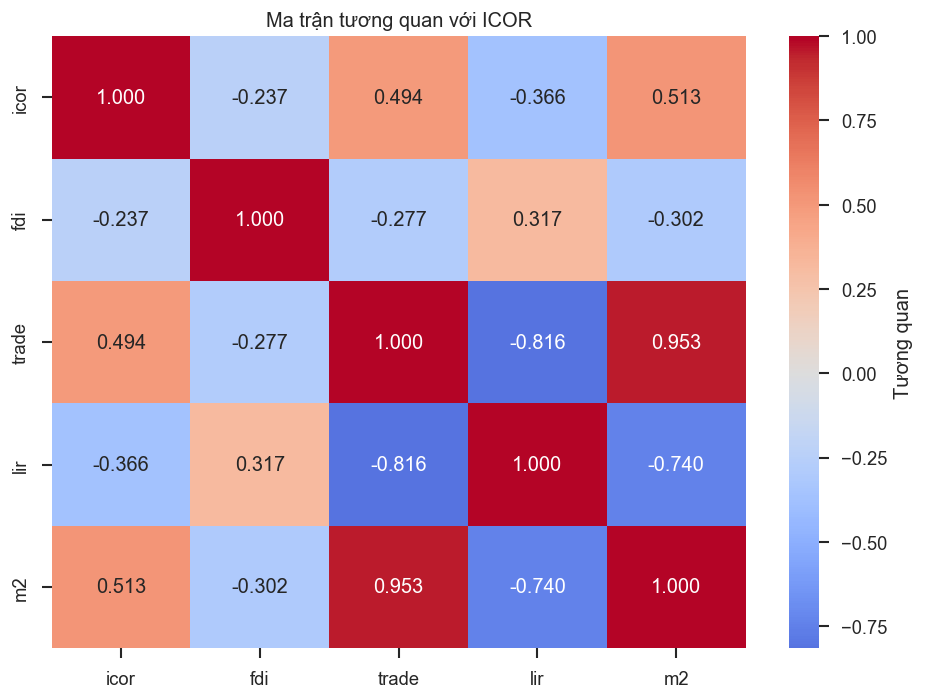

Ma trận tương quan:
        icor    fdi  trade    lir     m2
icor   1.000 -0.237  0.494 -0.366  0.513
fdi   -0.237  1.000 -0.277  0.317 -0.302
trade  0.494 -0.277  1.000 -0.816  0.953
lir   -0.366  0.317 -0.816  1.000 -0.740
m2     0.513 -0.302  0.953 -0.740  1.000


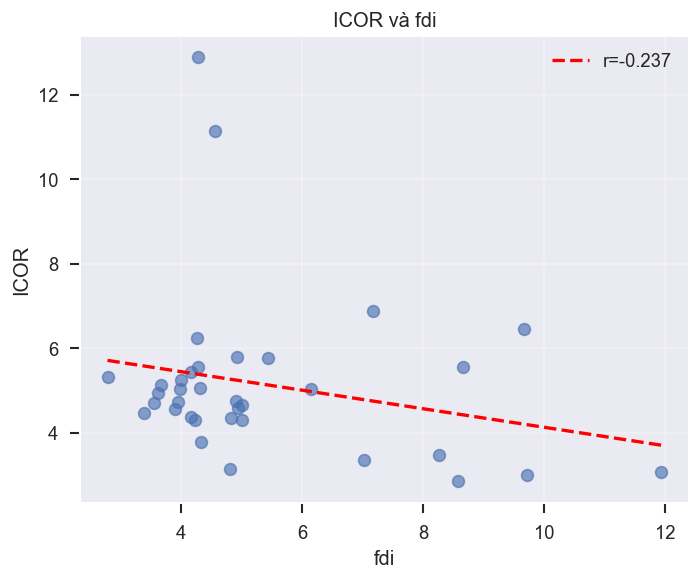

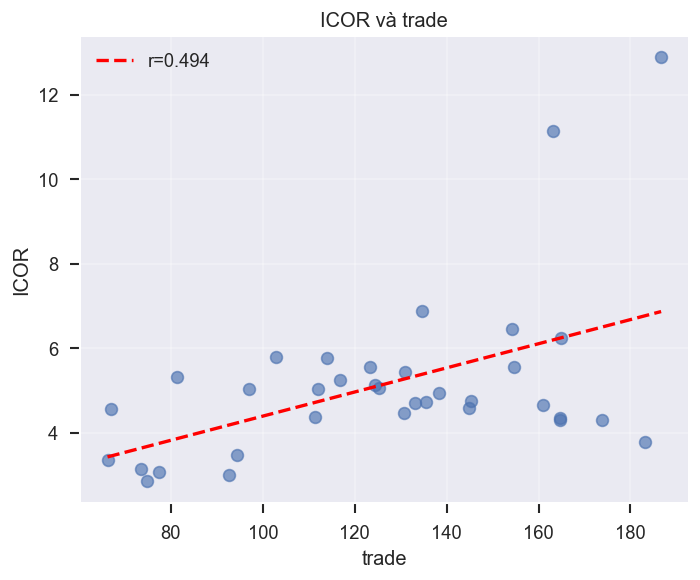

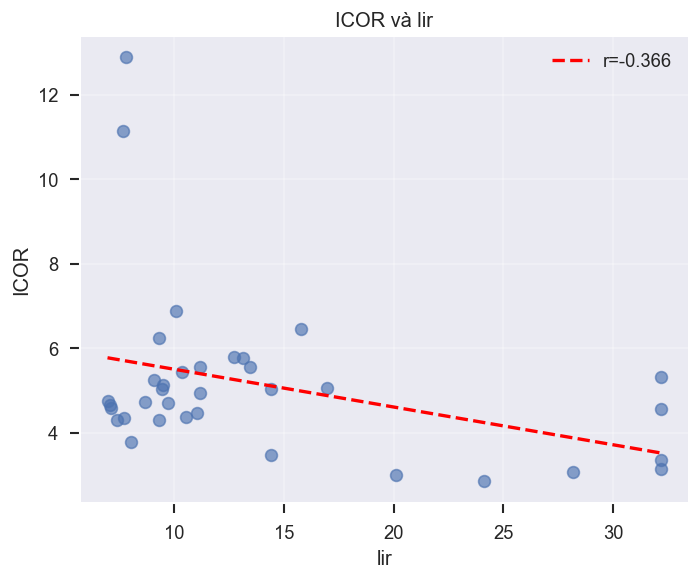

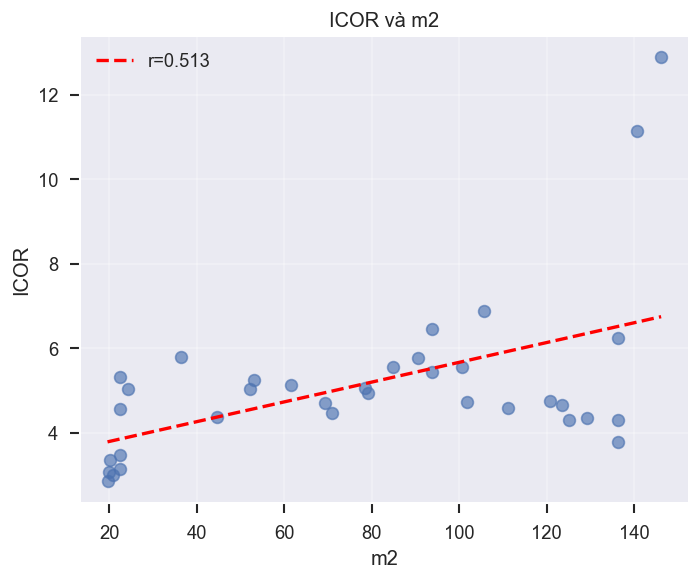

In [11]:
corr_cols = [col for col in ["icor", "fdi", "trade", "lir", "m2"] if col in df.columns]
print(f"Các biến dùng cho tương quan: {corr_cols}")

if len(corr_cols) < 2:
    raise ValueError("Không đủ biến để tính tương quan.")

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", cbar_kws={"label": "Tương quan"})
plt.title("Ma trận tương quan với ICOR")
plt.tight_layout()
plt.show()

print("Ma trận tương quan:")
print(corr.to_string(float_format=lambda x: f"{x:.3f}"))

for col in corr_cols:
    if col == "icor":
        continue

    valid = df[[col, "icor"]].dropna()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(valid[col], valid["icor"], alpha=0.65, s=50)

    if len(valid) >= 3:
        coef = np.polyfit(valid[col], valid["icor"], 1)
        x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_line, np.poly1d(coef)(x_line), "r--", linewidth=2, label=f"r={corr.loc['icor', col]:.3f}")

    ax.set_xlabel(col)
    ax.set_ylabel("ICOR")
    ax.set_title(f"ICOR và {col}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


**Nhận xét**

- ICOR tương quan dương vừa với M2 (r = 0.513) và thương mại (r = 0.494), tức các giai đoạn mở rộng tiền tệ/thương mại thường đi cùng ICOR cao hơn trong mẫu này.
- ICOR tương quan âm với lãi suất cho vay (r = -0.366) và FDI (r = -0.237), nhưng FDI không đủ mạnh để kết luận thống kê ở phần kiểm định sau.
- Đây là tương quan hai biến, chưa kiểm soát đồng thời các yếu tố vĩ mô nên không nên diễn giải là quan hệ nhân quả.


## 8. Diagnostic Analytics (Phân tích Chẩn đoán): Tại sao lại xảy ra?

Áp dụng kiểm định thống kê để tìm nguyên nhân:
- **Chow Test**: Kiểm định thay đổi cấu trúc sau các cú sốc (2008-2009 Khủng hoảng tài chính, 2020 COVID-19).
- **T-test**: Kiểm định sự khác biệt trung bình ICOR giữa Việt Nam và Thái Lan.
- **Correlation Test**: Kiểm định tương quan xem biến số nào ảnh hưởng đến ICOR.

In [12]:
def chow_test(y: np.ndarray, X: np.ndarray, break_year: int, years: np.ndarray):
    """Chow test đơn giản để kiểm tra thay đổi trung bình trước/sau mốc năm."""
    before = years < break_year
    y1, X1 = y[before], X[before]
    y2, X2 = y[~before], X[~before]

    if len(y1) <= X.shape[1] or len(y2) <= X.shape[1]:
        return np.nan, np.nan

    rss_full = sm.OLS(y, X).fit().ssr
    rss_1 = sm.OLS(y1, X1).fit().ssr
    rss_2 = sm.OLS(y2, X2).fit().ssr
    k = X.shape[1]
    n = len(y)
    stat = ((rss_full - (rss_1 + rss_2)) / k) / ((rss_1 + rss_2) / (n - 2 * k))
    p_value = stats.f.sf(stat, k, n - 2 * k)
    return stat, p_value


print("1. CHOW TEST (kiểm định thay đổi cấu trúc trung bình ICOR):")
valid_df = df[["year", "icor"]].dropna()
y = valid_df["icor"].to_numpy()
X = sm.add_constant(np.ones(len(valid_df)))
years = valid_df["year"].to_numpy()

chow_results = []
for break_year in [2008, 2020]:
    stat, p_value = chow_test(y, X, break_year, years)
    chow_results.append({"break_year": break_year, "stat": stat, "p_value": p_value})
    verdict = "có gãy khúc" if p_value < 0.05 else "chưa đủ bằng chứng"
    print(f"- {break_year}: stat={stat:.4f}, p-value={p_value:.4f} -> {verdict}")

print("\n2. TWO-SAMPLE T-TEST (ICOR Việt Nam và Thái Lan):")
thai_region = get_country_icor(raw, ["Thailand"], START_YEAR, END_YEAR)
thai_icor = thai_region["icor"].replace([np.inf, -np.inf], np.nan).dropna()
vn_icor = valid_df["icor"].replace([np.inf, -np.inf], np.nan).dropna()

t_stat, t_p_value = stats.ttest_ind(vn_icor, thai_icor, equal_var=False, nan_policy="omit")
print(f"- ICOR TB Việt Nam: {vn_icor.mean():.2f}")
print(f"- ICOR TB Thái Lan: {thai_icor.mean():.2f}")
print(f"- t-stat={t_stat:.4f}, p-value={t_p_value:.4f}")
print("  -> Có khác biệt ý nghĩa thống kê." if t_p_value < 0.05 else "  -> Chưa đủ bằng chứng về khác biệt trung bình.")

print("\n3. PEARSON CORRELATION TEST với ICOR:")
correlation_tests = []
for col in ["fdi", "gdp_growth", "trade", "lir", "m2"]:
    if col not in df.columns:
        continue
    valid = df[["icor", col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(valid) <= 5:
        continue
    r_value, p_value = pearsonr(valid["icor"], valid[col])
    correlation_tests.append({"Biến": col, "r": r_value, "p-value": p_value})
    verdict = "có ý nghĩa" if p_value < 0.05 else "không ý nghĩa"
    print(f"- {col.upper()}: r={r_value:.4f}, p-value={p_value:.4f} -> {verdict}")


1. CHOW TEST (kiểm định thay đổi cấu trúc trung bình ICOR):
- 2008: stat=6.0616, p-value=0.0192 -> có gãy khúc
- 2020: stat=12.8346, p-value=0.0011 -> có gãy khúc

2. TWO-SAMPLE T-TEST (ICOR Việt Nam và Thái Lan):
- ICOR TB Việt Nam: 5.14
- ICOR TB Thái Lan: 5.91
- t-stat=-0.4609, p-value=0.6476
  -> Chưa đủ bằng chứng về khác biệt trung bình.

3. PEARSON CORRELATION TEST với ICOR:
- FDI: r=-0.2373, p-value=0.1699 -> không ý nghĩa
- GDP_GROWTH: r=-0.8866, p-value=0.0000 -> có ý nghĩa
- TRADE: r=0.4945, p-value=0.0025 -> có ý nghĩa
- LIR: r=-0.3661, p-value=0.0305 -> có ý nghĩa
- M2: r=0.5133, p-value=0.0016 -> có ý nghĩa


**Nhận xét Diagnostic Analytics**

- Chow Test cho thấy có bằng chứng gãy khúc tại 2008 (p = 0.0192) và 2020 (p = 0.0011), phù hợp với các cú sốc kinh tế lớn.
- T-test Việt Nam - Thái Lan chỉ so sánh trung bình ICOR; kết luận cần dựa vào p-value in ở trên, không nên suy rộng thành khác biệt về toàn bộ chất lượng tăng trưởng.
- Pearson test cho thấy GDP growth có tương quan âm rất mạnh với ICOR; điều này đúng về mặt công thức vì GDP growth nằm ở mẫu số của ICOR.
- Trade, M2 và lãi suất có ý nghĩa thống kê trong mẫu này; FDI chưa đủ bằng chứng ở mức 5%.


## 9. Line chart ICOR gốc 1990-2023 (4 nước) — KHÔNG smoothing

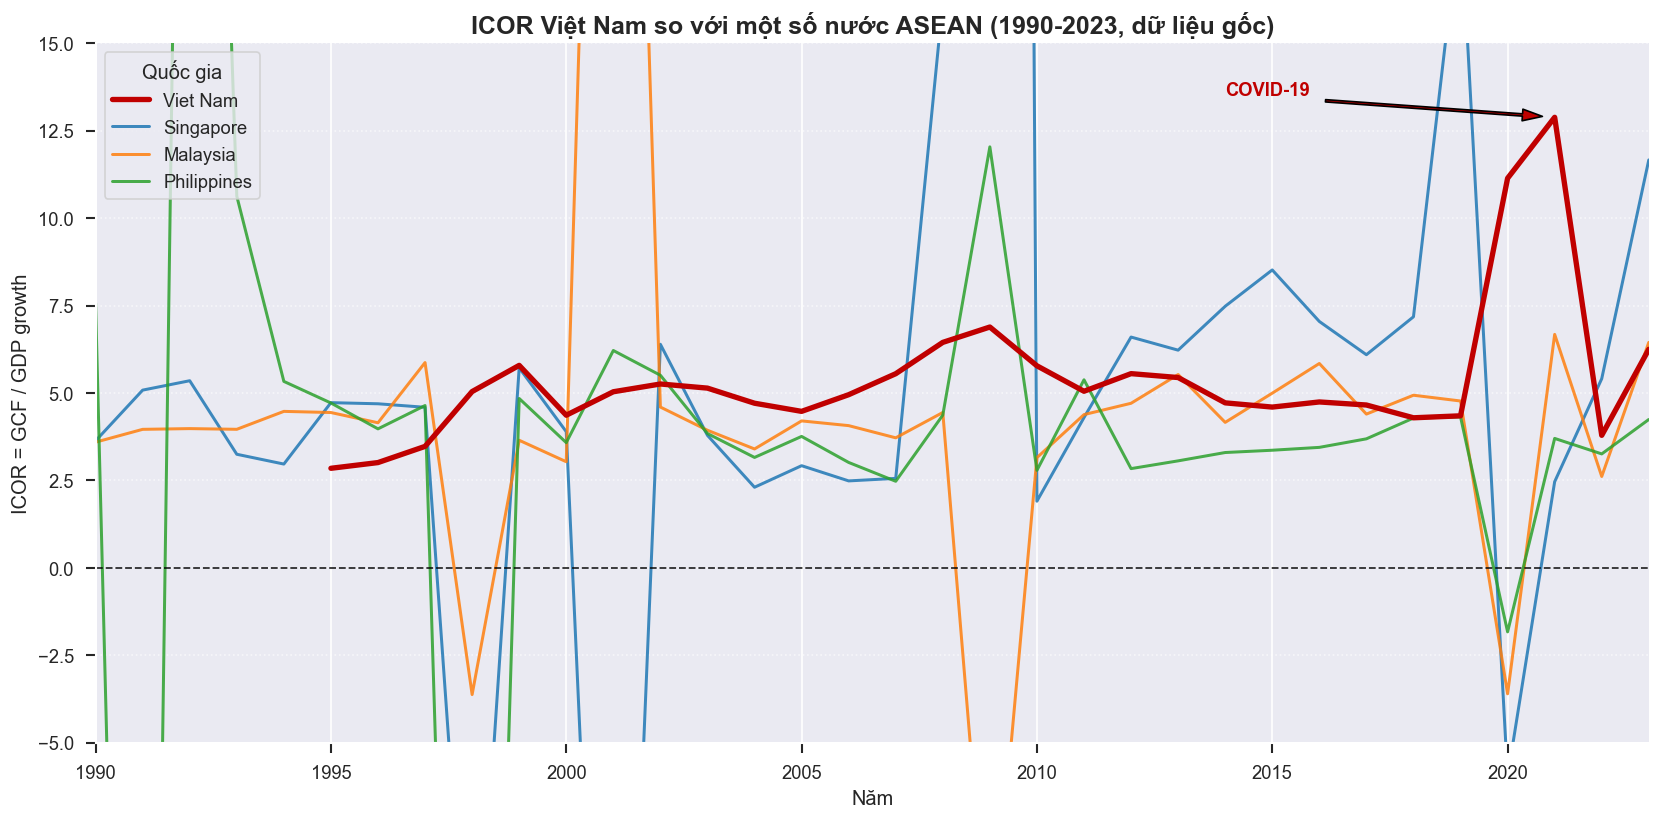

Tóm tắt ICOR 1990-2023:
               mean    std     min     max  count
Country Name                                     
Malaysia      4.710  8.237 -11.784  47.130     34
Philippines   2.972 14.020 -45.182  49.681     34
Singapore    10.055 36.789 -25.782 213.907     34
Viet Nam      5.385  2.065   2.845  12.881     29


In [13]:
if raw.get("gcf") is None or raw.get("gdp_growth") is None:
    raise RuntimeError("Thiếu dữ liệu GCF hoặc GDP growth để so sánh quốc tế.")

START_YEAR_LINE = 1990
END_YEAR_LINE = 2023
countries_line = ["Viet Nam", "Singapore", "Malaysia", "Philippines"]

region_line = get_country_icor(raw, countries_line, START_YEAR_LINE, END_YEAR_LINE)
icor_pivot_line = region_line.pivot(index="year", columns="Country Name", values="icor").sort_index()

color_map = {
    "Viet Nam": "#C00000",
    "Singapore": "#1f77b4",
    "Malaysia": "#ff7f0e",
    "Philippines": "#2ca02c",
}

plt.figure(figsize=(14, 7))
for country in countries_line:
    if country not in icor_pivot_line.columns:
        continue
    y = icor_pivot_line[country]
    is_vietnam = country == "Viet Nam"
    plt.plot(
        y.index,
        y.values,
        label=country,
        color=color_map[country],
        linewidth=3.2 if is_vietnam else 1.8,
        alpha=1.0 if is_vietnam else 0.85,
        zorder=5 if is_vietnam else 2,
    )

plt.title("ICOR Việt Nam so với một số nước ASEAN (1990-2023, dữ liệu gốc)", fontsize=15, fontweight="bold")
plt.xlabel("Năm")
plt.ylabel("ICOR = GCF / GDP growth")
plt.ylim(-5, 15)
plt.xlim(START_YEAR_LINE, END_YEAR_LINE)
plt.axhline(0, color="black", linewidth=1.1, linestyle="--", alpha=0.8)

if 2021 in icor_pivot_line.index and "Viet Nam" in icor_pivot_line.columns:
    vn_2021 = icor_pivot_line.loc[2021, "Viet Nam"]
    if pd.notna(vn_2021):
        plt.annotate(
            "COVID-19",
            xy=(2021, vn_2021),
            xytext=(2014, 13.5),
            arrowprops=dict(facecolor="#C00000", shrink=0.05, width=1.4, headwidth=7),
            fontsize=11,
            color="#C00000",
            fontweight="bold",
        )

sns.despine(top=True, right=True)
plt.grid(True, axis="y", linestyle=":", alpha=0.6)
plt.legend(title="Quốc gia", loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

comparison_summary = region_line.groupby("Country Name")["icor"].agg(["mean", "std", "min", "max", "count"])
print("Tóm tắt ICOR 1990-2023:")
print(comparison_summary.to_string(float_format=lambda x: f"{x:.3f}"))


**Nhận xét**

- Việt Nam nổi bật ở các năm 2020-2021 do ICOR tăng mạnh trong cú sốc tăng trưởng, không phải vì GCF tăng đột biến tương ứng.
- Việc cắt trục Y từ -5 đến 15 giúp đọc xu hướng chính tốt hơn, nhưng các giá trị cực đoan ngoài khoảng này vẫn cần kiểm tra riêng nếu phân tích sâu từng nước.
- So sánh quốc tế chỉ nên xem là benchmark mô tả vì cơ cấu đầu tư, chu kỳ kinh tế và cách ghi nhận dữ liệu giữa các nước khác nhau.


## 10. Predictive Analytics (Phân tích Dự đoán): Điều gì sẽ xảy ra trong thời gian tới?

Sử dụng dữ liệu quá khứ để xây dựng mô hình dự báo cho 5 năm tới (2025-2029).
Kỹ thuật áp dụng là **ARIMAX**.
Trước khi dựng mô hình, ta cần thực hiện **ADF Test** để kiểm tra tính dừng của chuỗi.

In [14]:
print("KIỂM ĐỊNH ADF TEST CHO ICOR GỐC:")
icor_s = df["icor"].replace([np.inf, -np.inf], np.nan).dropna()
adf_stat, adf_pvalue, *_rest, critical_values, _icbest = adfuller(icor_s)

print(f"- ADF Statistic: {adf_stat:.4f}")
print(f"- p-value: {adf_pvalue:.4f}")
for level, value in critical_values.items():
    print(f"  Critical Value {level}: {value:.4f}")

if adf_pvalue < 0.05:
    print("\nKết luận: Chuỗi ICOR gốc dừng ở mức 5%; ARIMAX có thể chọn d=0 nếu AIC ủng hộ.")
else:
    print("\nKết luận: Chưa đủ bằng chứng chuỗi ICOR gốc dừng; ARIMAX cần cân nhắc sai phân.")


KIỂM ĐỊNH ADF TEST CHO ICOR GỐC:
- ADF Statistic: -3.2186
- p-value: 0.0189
  Critical Value 1%: -3.6614
  Critical Value 5%: -2.9605
  Critical Value 10%: -2.6193

Kết luận: Chuỗi ICOR gốc dừng ở mức 5%; ARIMAX có thể chọn d=0 nếu AIC ủng hộ.


## 11. ARIMAX tự động với `macro_shock` (1990-2024)

Quy tắc cốt lõi: **KHÔNG smoothing / moving average** — chỉ dùng chuỗi ICOR gốc.

4 bước:
- Bước 1: Tạo biến sốc vĩ mô `macro_shock` từ Z-score của ICOR (|z| > 2.5 ⇒ 1, ngược lại 0)
- Bước 2: Auto chọn (p,d,q,trend) bằng grid search (AIC trên train)
- Bước 3: Train/Test: test = 3 năm cuối; in RMSE, MAPE và p-value Ljung-Box
- Bước 4: Fit lại trên toàn bộ dữ liệu và dự báo 5 năm tới (giả định `macro_shock=0`), kèm CI 95%

Ghi chú: Trong `statsmodels`, ARIMAX được fit bằng `SARIMAX(..., exog=...)` với `seasonal_order=(0,0,0,0)`.

In [15]:
series = df.set_index("year")["icor"].replace([np.inf, -np.inf], np.nan).dropna().sort_index()

z = (series - series.mean()) / series.std(ddof=0)
macro_shock = (z.abs() > 2.5).astype(int)
exog_full = pd.DataFrame({"macro_shock": macro_shock.values}, index=series.index)
shock_years = series.index[macro_shock == 1].astype(int).tolist()
print("Năm macro_shock=1 (|Z| > 2.5):", shock_years if shock_years else "(không có)")

if len(series) < 10:
    raise RuntimeError("Chuỗi ICOR quá ngắn để fit ARIMAX.")

test_size = 3
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]
exog_train = exog_full.loc[train.index]
exog_test = exog_full.loc[test.index]

print(f"Train: {int(train.index.min())}-{int(train.index.max())} (n={len(train)})")
print(f"Test : {int(test.index.min())}-{int(test.index.max())} (n={len(test)})")

p_range = range(0, 5)
d_range = [0, 1, 2]
q_range = range(0, 5)
trend_options = ["n", "c"]

results = []
for p, d, q, trend in itertools.product(p_range, d_range, q_range, trend_options):
    if p + q > 6:
        continue
    try:
        fit = sm.tsa.statespace.SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(0, 0, 0, 0),
            exog=exog_train,
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        results.append({"p": p, "d": d, "q": q, "trend": trend, "aic": float(fit.aic), "bic": float(fit.bic)})
    except Exception:
        continue

grid = pd.DataFrame(results).sort_values(["aic", "bic"]).reset_index(drop=True)
if grid.empty:
    raise RuntimeError("Grid search thất bại: không fit được mô hình ARIMAX nào.")

best = grid.iloc[0]
arima_order = (int(best.p), int(best.d), int(best.q))
arima_trend = str(best.trend)

print("\nTop 10 mô hình theo AIC trên train:")
print(grid.head(10).to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nChọn ARIMAX{arima_order}, trend='{arima_trend}' (AIC={best.aic:.3f}, BIC={best.bic:.3f})")


Năm macro_shock=1 (|Z| > 2.5): [2020, 2021]
Train: 1990-2021 (n=32)
Test : 2022-2024 (n=3)

Top 10 mô hình theo AIC trên train:
 p  d  q trend    aic    bic
 2  0  2     c 59.682 69.253
 1  0  4     c 59.769 70.136
 1  0  3     c 59.966 69.291
 2  0  4     c 61.228 72.890
 1  0  2     c 61.455 69.658
 2  1  3     n 62.486 71.557
 0  1  3     c 62.905 70.680
 0  1  2     n 63.177 68.506
 0  1  4     c 63.229 72.035
 0  1  3     n 63.291 69.770

Chọn ARIMAX(2, 0, 2), trend='c' (AIC=59.682, BIC=69.253)


### Bước 3) Train/Test (test = 3 năm cuối)

- **Test:** 3 năm cuối của chuỗi ICOR
- **Train:** phần còn lại

In: RMSE, MAPE và p-value Ljung-Box (residuals trên train).

ARIMAX(2, 0, 2), trend='c'
RMSE=1.787 | MAPE=35.93% | Ljung-Box p-value(lag 10)=0.7817


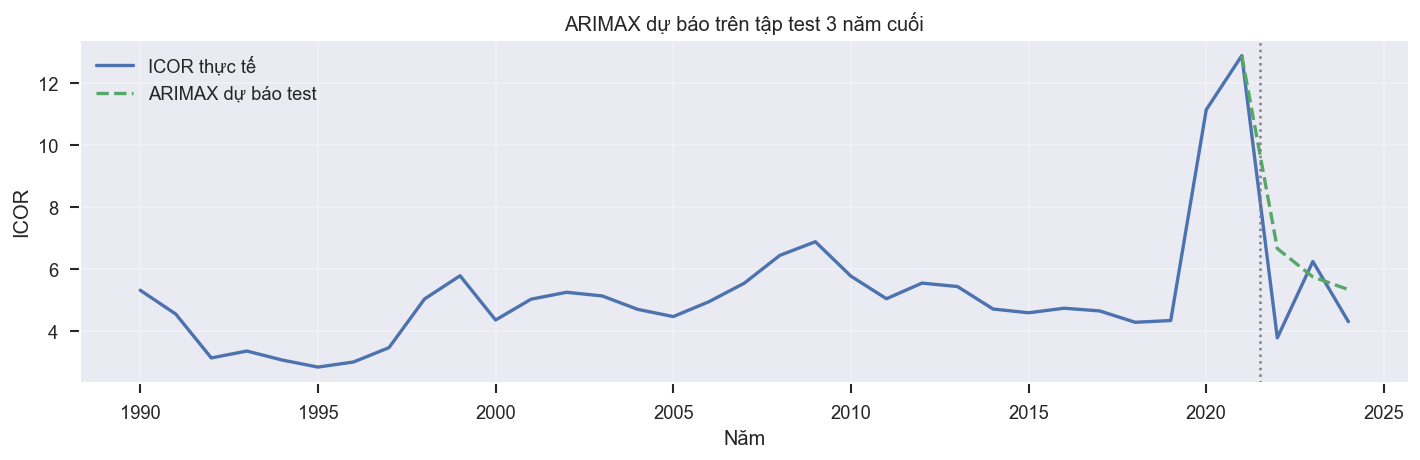

In [16]:
arimax_fit = sm.tsa.statespace.SARIMAX(
    train,
    order=arima_order,
    seasonal_order=(0, 0, 0, 0),
    exog=exog_train,
    trend=arima_trend,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

pred_test = arimax_fit.get_forecast(steps=len(test), exog=exog_test).predicted_mean
rmse = float(np.sqrt(np.mean((test.values - pred_test.values) ** 2)))
mape = float(np.mean(np.abs((test.values - pred_test.values) / (np.abs(test.values) + 1e-8))) * 100)

resid = pd.Series(arimax_fit.resid).dropna()
lb_lag = min(10, max(1, len(resid) // 2))
lb = acorr_ljungbox(resid, lags=[lb_lag], return_df=True)
ljungbox_p = float(lb.loc[lb_lag, "lb_pvalue"])

print(f"ARIMAX{arima_order}, trend='{arima_trend}'")
print(f"RMSE={rmse:.3f} | MAPE={mape:.2f}% | Ljung-Box p-value(lag {lb_lag})={ljungbox_p:.4f}")

plt.figure(figsize=(12, 4))
actual_full = pd.concat([train, test]).sort_index()
plt.plot(actual_full.index, actual_full.values, label="ICOR thực tế", linewidth=2)

x_pred = np.concatenate([[train.index[-1]], test.index.values])
y_pred = np.concatenate([[train.iloc[-1]], pred_test.values])
plt.plot(x_pred, y_pred, "--", label="ARIMAX dự báo test", linewidth=2)

plt.axvline(test.index.min() - 0.5, color="gray", linestyle=":")
plt.title("ARIMAX dự báo trên tập test 3 năm cuối")
plt.xlabel("Năm")
plt.ylabel("ICOR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

train_model = arimax_fit
forecast_test = pred_test


**Nhận xét**

- Mô hình được chọn theo AIC là ARIMAX(2, 0, 2) với hằng số; lựa chọn `d=0` nhất quán với ADF test cho thấy chuỗi ICOR gốc dừng.
- Test chỉ có 3 năm cuối nên RMSE và MAPE dùng để tham khảo, không đủ để khẳng định năng lực dự báo dài hạn.
- Ljung-Box p-value khoảng 0.78 cho thấy chưa phát hiện tự tương quan đáng kể trong phần dư ở lag kiểm định.


### Bước 3b) Diagnostics nhanh (Ljung-Box)

Đã in p-value Ljung-Box ở bước trên. (Không dùng smoothing).

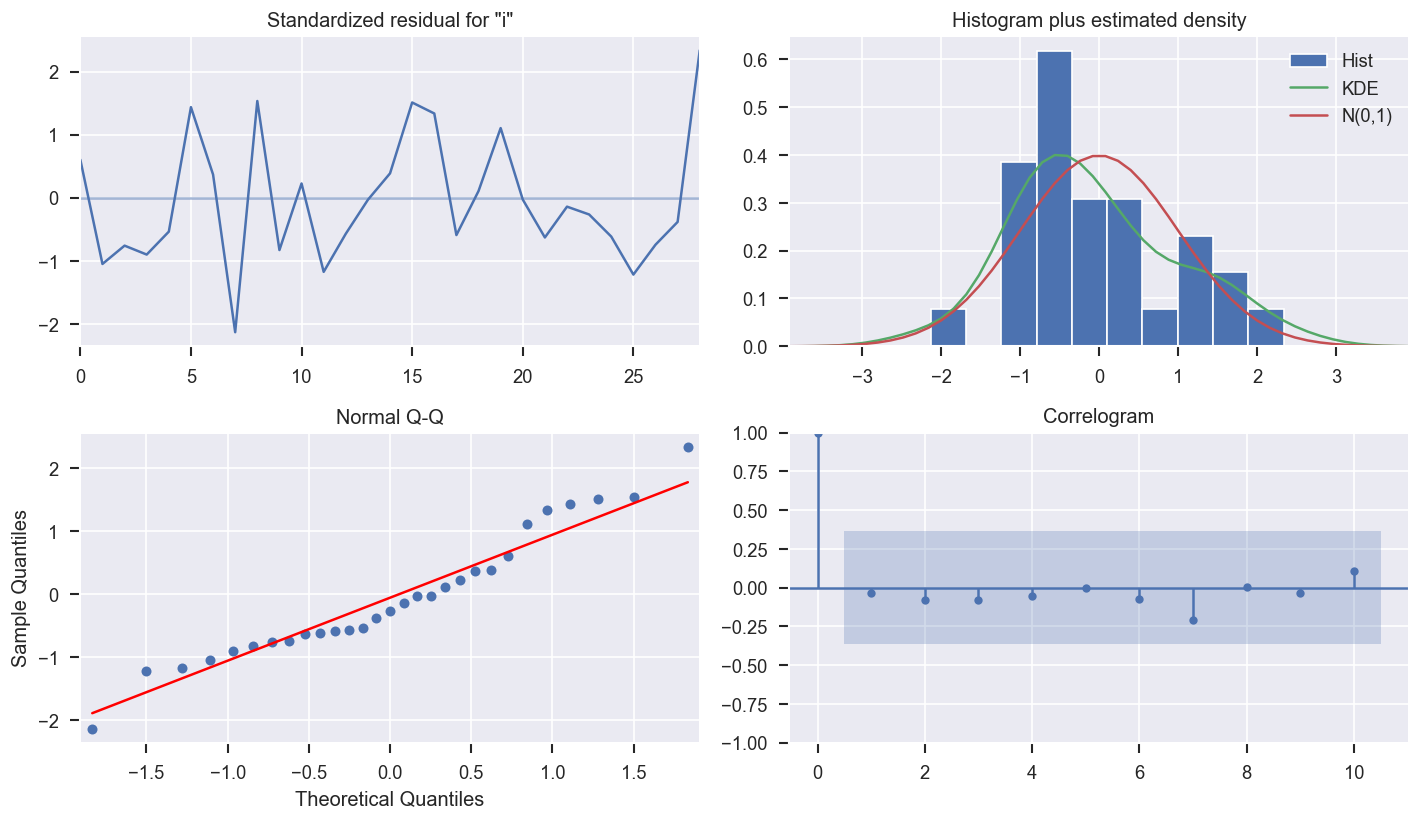

In [17]:
# (Tuỳ chọn) Xem diagnostics tổng quan của mô hình ARIMAX
if "train_model" not in globals():
    raise RuntimeError("Chưa có train_model (chạy Bước 3 trước)")

train_model.plot_diagnostics(figsize=(12, 7))
plt.tight_layout()
plt.show()


**Nhận xét**

- Biểu đồ diagnostics dùng để kiểm tra nhanh phần dư: phần dư nên dao động quanh 0, phân phối không quá lệch và ACF không còn cấu trúc rõ.
- Kết hợp với Ljung-Box, mô hình hiện không cho tín hiệu tự tương quan phần dư nghiêm trọng.
- Dù vậy, mẫu chỉ có 35 quan sát nên kết quả diagnostics cần được đọc thận trọng.


### Bước 4) Dự báo 5 năm tới (ARIMAX + `macro_shock`)

- Fit lại ARIMAX trên toàn bộ dữ liệu.
- Dự báo 5 năm sau năm cuối với **`macro_shock=0` trong tương lai**.
- Vẽ đường dự báo kèm dải tin cậy 95%.

Forecast 2025-2029 (mean & 95% CI):
 year  forecast  lower_95  upper_95
 2025     5.547     4.089     7.005
 2026     4.343     2.702     5.984
 2027     5.131     3.201     7.061
 2028     4.533     2.587     6.480
 2029     4.931     2.937     6.925


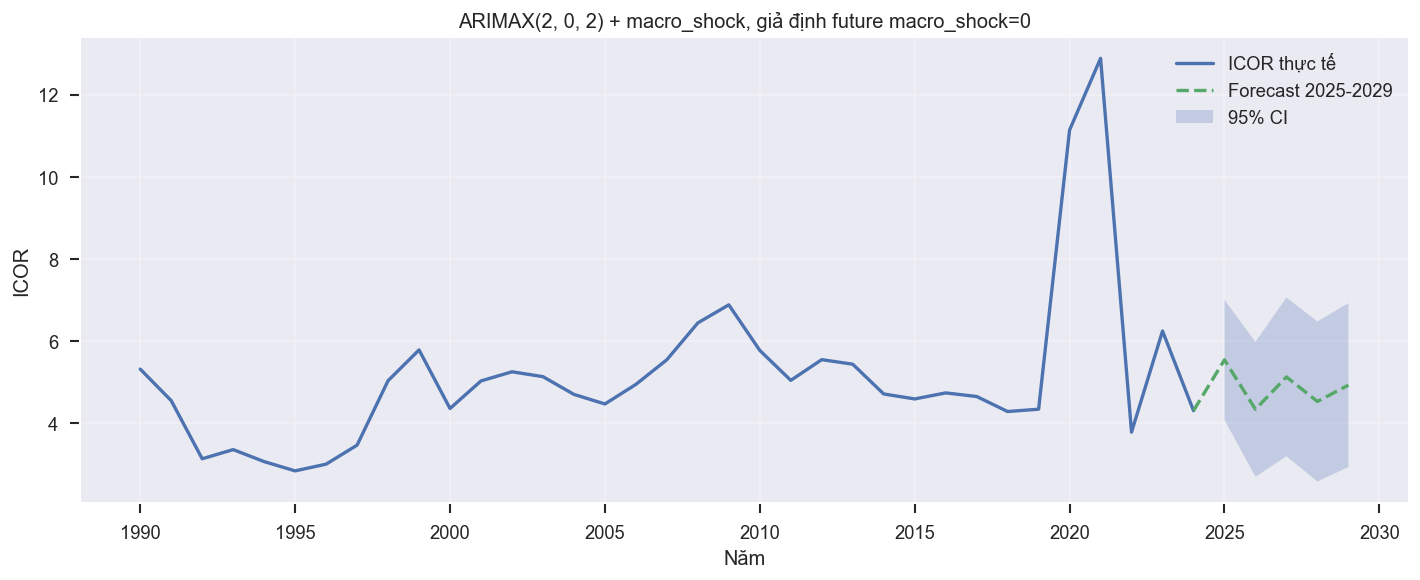

In [18]:
final_model = sm.tsa.statespace.SARIMAX(
    series,
    order=arima_order,
    seasonal_order=(0, 0, 0, 0),
    exog=exog_full,
    trend=arima_trend,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

last_year = int(series.index.max())
forecast_years = np.arange(last_year + 1, last_year + 6)
exog_future = pd.DataFrame({"macro_shock": np.zeros(len(forecast_years), dtype=int)}, index=forecast_years)

forecast_result = final_model.get_forecast(steps=len(forecast_years), exog=exog_future)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

out = pd.DataFrame(
    {
        "year": forecast_years,
        "forecast": forecast_mean.values,
        "lower_95": conf_int.iloc[:, 0].values,
        "upper_95": conf_int.iloc[:, 1].values,
    }
)

print(f"Forecast {forecast_years[0]}-{forecast_years[-1]} (mean & 95% CI):")
print(out.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, label="ICOR thực tế", linewidth=2)

x_fc = np.concatenate([[last_year], forecast_years])
y_fc = np.concatenate([[float(series.loc[last_year])], forecast_mean.values])
plt.plot(x_fc, y_fc, "--", label=f"Forecast {forecast_years[0]}-{forecast_years[-1]}", linewidth=2)
plt.fill_between(forecast_years, conf_int.iloc[:, 0].values, conf_int.iloc[:, 1].values, alpha=0.25, label="95% CI")

plt.title(f"ARIMAX{arima_order} + macro_shock, giả định future macro_shock=0")
plt.xlabel("Năm")
plt.ylabel("ICOR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Nhận xét**

- Dự báo 2025-2029 dao động quanh 4.3-5.5, thấp hơn rõ so với đỉnh COVID-19 nhưng vẫn nằm trong vùng ICOR lịch sử của Việt Nam.
- Khoảng tin cậy 95% khá rộng, phản ánh độ bất định lớn của chuỗi ngắn và các cú sốc gần đây.
- Giả định `macro_shock=0` nghĩa là kịch bản cơ sở không có cú sốc bất thường; nếu có cú sốc mới, dự báo cần cập nhật lại.


## 12. Tóm tắt nhanh ARIMAX

In [19]:
print(f"ARIMAX{arima_order}, trend='{arima_trend}'")
print(f"Test 3 năm cuối | RMSE={rmse:.3f} | MAPE={mape:.2f}% | Ljung-Box p={ljungbox_p:.4f}")
print("Macro shock years (|Z| > 2.5):", shock_years if shock_years else "(không có)")

print(f"\nForecast {int(out['year'].min())}-{int(out['year'].max())} (mean & 95% CI):")
print(out.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


ARIMAX(2, 0, 2), trend='c'
Test 3 năm cuối | RMSE=1.787 | MAPE=35.93% | Ljung-Box p=0.7817
Macro shock years (|Z| > 2.5): [2020, 2021]

Forecast 2025-2029 (mean & 95% CI):
 year  forecast  lower_95  upper_95
 2025     5.547     4.089     7.005
 2026     4.343     2.702     5.984
 2027     5.131     3.201     7.061
 2028     4.533     2.587     6.480
 2029     4.931     2.937     6.925


## 14. Phân tích độ trễ tối ưu cho ICOR

Phần này được tích hợp từ `lag_analysis.py` để kiểm tra độ trễ hợp lý giữa đầu tư và tăng trưởng GDP. Nội dung gồm ba hướng: cross-correlation giữa GCF(t-k) và ΔGDP(t), so sánh ICOR theo các lag k=0..5, và kiểm định Granger causality.


### Mục tiêu phân tích

Phân tích Lag tối ưu cho ICOR Việt Nam
========================================
Mục tiêu:
1. Cross-correlation giữa Đầu tư(t-k) và ΔGDP(t) với k = 0,1,2,3,4,5
2. Tính ICOR với từng giả định lag (0–5) → so sánh tính ổn định & hợp lý (3–6)
3. Kiểm định Granger causality: đầu tư ở lag nào "dẫn dắt" tăng trưởng GDP mạnh nhất

Dữ liệu: World Bank CSV – GCF (% GDP) và GDP growth (%)


In [20]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_context("notebook")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 120,
})

# ---------- 0. CONFIG & DATA LOADING ----------
BASE_DIR = Path(BASE_DIR) if "BASE_DIR" in globals() else Path.cwd()
START_YEAR = 1990
END_YEAR = 2024
MAX_LAG = 34  # k = 0..34

OUTPUT_DIR = BASE_DIR / "lag_analysis_output"
OUTPUT_DIR.mkdir(exist_ok=True)


def read_wb_csv(path: Path) -> pd.DataFrame | None:
    """Đọc CSV World Bank, bỏ 4 dòng metadata đầu."""
    if not path.exists():
        print(f"  [THIẾU] {path}")
        return None
    df = pd.read_csv(path, skiprows=4)
    print(f"  [OK] {path.name}: {df.shape}")
    return df


def to_long_vn(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    """Wide → long cho Việt Nam."""
    if df is None:
        return pd.DataFrame(columns=["year", value_name])
    data = df[df["Country Name"].str.casefold() == "viet nam"].copy()
    year_cols = [c for c in data.columns if str(c).isdigit()]
    id_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
    long = data[id_cols + year_cols].melt(id_vars=id_cols, var_name="year", value_name=value_name)
    long["year"] = long["year"].astype(int)
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")
    return long[["year", value_name]]


print("=" * 70)
print("BƯỚC 0: ĐỌC VÀ CHUẨN BỊ DỮ LIỆU")
print("=" * 70)

gcf_path = BASE_DIR / "GCF" / "API_NE.GDI.TOTL.ZS_DS2_en_csv_v2_115698.csv"
gdp_path = BASE_DIR / "GDP" / "API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_121708.csv"

raw_gcf = read_wb_csv(gcf_path)
raw_gdp = read_wb_csv(gdp_path)

gcf_long = to_long_vn(raw_gcf, "gcf")
gdp_long = to_long_vn(raw_gdp, "gdp_growth")

df = gcf_long.merge(gdp_long, on="year", how="inner")
df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)].copy()
df = df.sort_values("year").reset_index(drop=True)

# Nội suy nếu thiếu
df = df.set_index("year").interpolate(method="linear", limit_direction="both").reset_index()

# ΔGDP – sai phân bậc 1 của GDP growth
df["delta_gdp"] = df["gdp_growth"].diff()

print(f"\nDữ liệu sẵn sàng: {len(df)} năm ({df['year'].min()}–{df['year'].max()})")
print(df[["year", "gcf", "gdp_growth", "delta_gdp"]].to_string(index=False))
print()

# ====================================================================


BƯỚC 0: ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
  [OK] API_NE.GDI.TOTL.ZS_DS2_en_csv_v2_115698.csv: (266, 71)
  [OK] API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_121708.csv: (266, 71)

Dữ liệu sẵn sàng: 35 năm (1990–2024)
 year       gcf  gdp_growth  delta_gdp
 1990 27.144243    5.100918        NaN
 1991 27.144243    5.960844   0.859926
 1992 27.144243    8.646047   2.685204
 1993 27.144243    8.072731  -0.573317
 1994 27.144243    8.838981   0.766250
 1995 27.144243    9.540480   0.701499
 1996 28.102898    9.340017  -0.200463
 1997 28.299583    8.152084  -1.187933
 1998 29.049879    5.764455  -2.387629
 1999 27.629756    4.773587  -0.990869
 2000 29.609914    6.787316   2.013730
 2001 31.172773    6.192893  -0.594423
 2002 33.220534    6.320821   0.127928
 2003 35.444858    6.899063   0.578242
 2004 35.465332    7.536411   0.637347
 2005 33.757403    7.547248   0.010837
 2006 34.536651    6.977955  -0.569293
 2007 39.566271    7.129504   0.151550
 2008 36.493122    5.661771  -1.467733
 2009 37.162555    5.39

### Phần 1: Cross-correlation - Đầu tư(t-k) và ΔGDP(t)


PHẦN 1: CROSS-CORRELATION  –  Investment(t-k)  vs  ΔGDP(t)

>>> Bảng Cross-Correlation: Investment(t-k) & ΔGDP(t)
 lag_k  n_obs  pearson_r  p_value
     0     34  -0.036147 0.839170
     1     33  -0.059366 0.742782
     2     32  -0.004804 0.979183
     3     31   0.030248 0.871677
     4     30   0.037868 0.842520
     5     29   0.038810 0.841575
     6     28   0.110309 0.576299
     7     27   0.162503 0.418034
     8     26   0.002482 0.990400
     9     25  -0.054013 0.797623
    10     24  -0.130801 0.542384
    11     23  -0.084977 0.699860
    12     22   0.058664 0.795388
    13     21  -0.083991 0.717378
    14     20   0.084514 0.723148
    15     19   0.235170 0.332458
    16     18  -0.110246 0.663209
    17     17   0.024561 0.925452
    18     16   0.087019 0.748629
    19     15   0.100556 0.721414
    20     14   0.119383 0.684374
    21     13   0.203769 0.504305
    22     12   0.045216 0.889029
    23     11  -0.137378 0.687098
    24     10   0.413832 0.234494
  

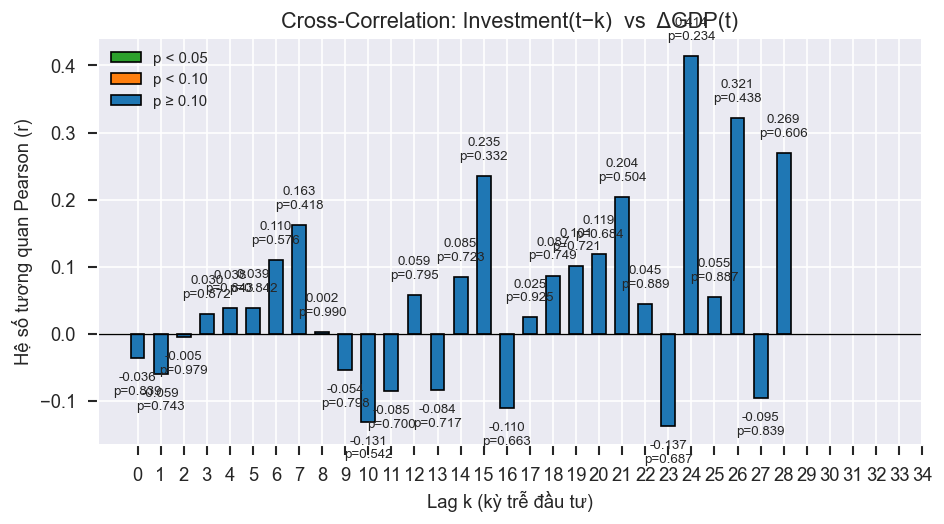


[Lưu biểu đồ] d:\HK2- 2025-2026\DATA Analyst\Đợt 1\lag_analysis_output\01_cross_correlation.png


In [21]:
# PHẦN 1: CROSS-CORRELATION – Đầu tư(t-k) vs ΔGDP(t)
# ====================================================================
print("=" * 70)
print("PHẦN 1: CROSS-CORRELATION  –  Investment(t-k)  vs  ΔGDP(t)")
print("=" * 70)

# Lấy chuỗi hợp lệ (bỏ NaN do diff)
valid = df.dropna(subset=["delta_gdp"]).copy()

results_cc = []
for k in range(MAX_LAG + 1):
    # GCF(t-k) → lag k kỳ → dịch chuỗi GCF về trước k bước
    shifted = valid["gcf"].shift(k)
    mask = shifted.notna() & valid["delta_gdp"].notna()
    x = shifted[mask].values
    y = valid.loc[mask, "delta_gdp"].values
    n = len(x)
    if n < 5:
        continue
    r, pval = pearsonr(x, y)
    results_cc.append({"lag_k": k, "n_obs": n, "pearson_r": r, "p_value": pval})

cc_df = pd.DataFrame(results_cc)
print("\n>>> Bảng Cross-Correlation: Investment(t-k) & ΔGDP(t)")
print(cc_df.to_string(index=False))

# Xác định lag tốt nhất (|r| lớn nhất & p < 0.10)
best_cc = cc_df.loc[cc_df["pearson_r"].abs().idxmax()]
print(f"\n→ Lag có |r| lớn nhất: k = {int(best_cc['lag_k'])} "
      f"(r = {best_cc['pearson_r']:.4f}, p = {best_cc['p_value']:.4f})")
sig = cc_df[cc_df["p_value"] < 0.10]
if not sig.empty:
    best_sig = sig.loc[sig["pearson_r"].abs().idxmax()]
    print(f"→ Lag có ý nghĩa thống kê (p < 0.10) & |r| cao nhất: k = {int(best_sig['lag_k'])} "
          f"(r = {best_sig['pearson_r']:.4f}, p = {best_sig['p_value']:.4f})")
else:
    print("  (Không có lag nào có p < 0.10)")

# --- Biểu đồ cross-correlation ---
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#2ca02c' if p < 0.05 else ('#ff7f0e' if p < 0.10 else '#1f77b4')
          for p in cc_df["p_value"]]
bars = ax.bar(cc_df["lag_k"], cc_df["pearson_r"], color=colors, edgecolor="black", width=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag k (kỳ trễ đầu tư)")
ax.set_ylabel("Hệ số tương quan Pearson (r)")
ax.set_title("Cross-Correlation: Investment(t−k)  vs  ΔGDP(t)")
ax.set_xticks(range(MAX_LAG + 1))
for i, row in cc_df.iterrows():
    ax.text(row["lag_k"], row["pearson_r"] + 0.02 * np.sign(row["pearson_r"]),
            f'{row["pearson_r"]:.3f}\np={row["p_value"]:.3f}',
            ha="center", va="bottom" if row["pearson_r"] >= 0 else "top", fontsize=8)
# Legend thủ công
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', edgecolor='black', label='p < 0.05'),
    Patch(facecolor='#ff7f0e', edgecolor='black', label='p < 0.10'),
    Patch(facecolor='#1f77b4', edgecolor='black', label='p ≥ 0.10'),
]
ax.legend(handles=legend_elements, loc="best", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_cross_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[Lưu biểu đồ] {OUTPUT_DIR / '01_cross_correlation.png'}")

# ====================================================================


### Phần 2: So sánh ICOR theo từng lag



PHẦN 2: ICOR THEO TỪNG LAG (k=0..5)  –  SO SÁNH ỔN ĐỊNH & HỢP LÝ

>>> Bảng tổng hợp ICOR theo từng Lag
 lag_k  n_obs  mean  median   std    CV%   min    max  n_in_3-6  %_in_3-6
     0     35 5.141   4.742 1.982 38.562 2.845 12.881        29    82.857
     1     34 5.122   4.743 2.000 39.045 2.845 12.498        26    76.471
     2     33 5.126   4.627 2.059 40.170 2.845 12.523        25    75.758
     3     32 5.165   4.578 2.073 40.133 2.845 12.538        23    71.875
     4     31 5.196   4.596 2.087 40.172 2.845 12.650        21    67.742
     5     30 5.246   4.599 2.096 39.948 2.845 12.423        21    70.000
     6     29 5.292   4.664 2.038 38.506 2.906 12.573        22    75.862
     7     28 5.322   4.966 1.894 35.595 3.330 11.861        21    75.000
     8     27 5.364   5.172 1.897 35.365 3.548 11.831        22    81.481
     9     26 5.372   4.961 2.020 37.597 3.539 11.967        22    84.615
    10     25 5.382   4.861 2.371 44.053 3.579 12.947        21    84.000
    11  

IndexError: index 6 is out of bounds for axis 0 with size 6

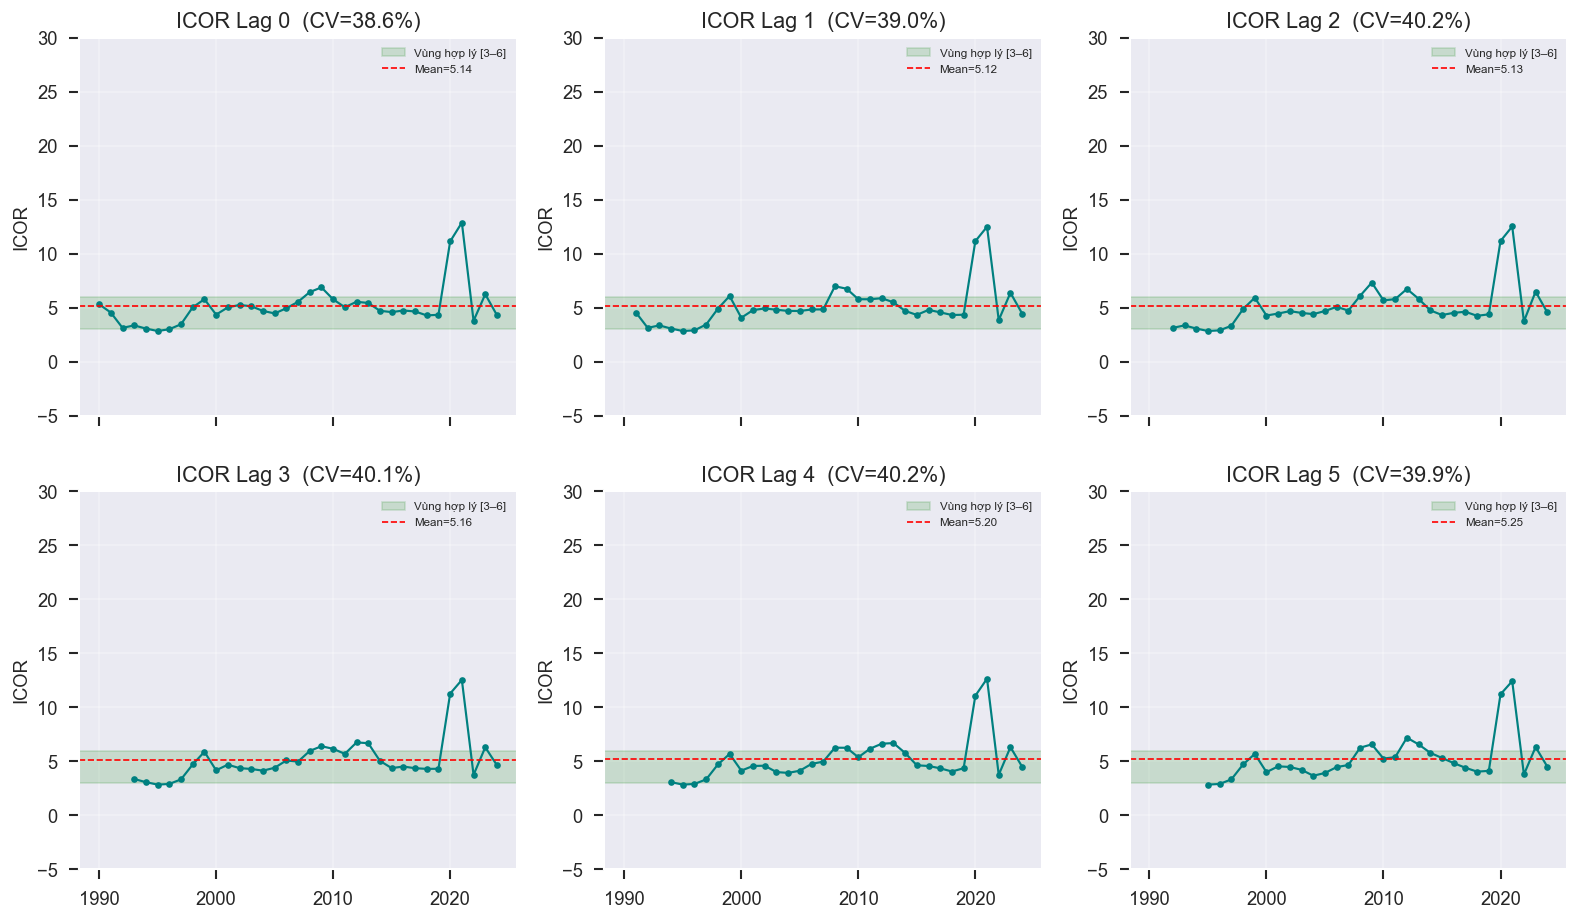

In [22]:
# PHẦN 2: ICOR THEO TỪNG LAG – SO SÁNH TÍNH ỔN ĐỊNH & HỢP LÝ
# ====================================================================
print("\n" + "=" * 70)
print("PHẦN 2: ICOR THEO TỪNG LAG (k=0..5)  –  SO SÁNH ỔN ĐỊNH & HỢP LÝ")
print("=" * 70)

REASONABLE_LOW = 3.0
REASONABLE_HIGH = 6.0

icor_summary = []
icor_series = {}

for k in range(MAX_LAG + 1):
    col = f"icor_lag{k}"
    # ICOR(t, lag_k) = GCF(t-k) / GDP_growth(t)
    gcf_shifted = df["gcf"].shift(k)
    # Bỏ năm GDP growth <= 0 (ICOR vô nghĩa khi suy thoái)
    mask = (df["gdp_growth"] > 0) & gcf_shifted.notna()
    icor_vals = gcf_shifted[mask] / df.loc[mask, "gdp_growth"]
    years_valid = df.loc[mask, "year"]

    icor_series[k] = pd.DataFrame({"year": years_valid, "icor": icor_vals.values})

    # Thống kê
    n_in_range = ((icor_vals >= REASONABLE_LOW) & (icor_vals <= REASONABLE_HIGH)).sum()
    pct_in_range = n_in_range / len(icor_vals) * 100 if len(icor_vals) > 0 else 0
    cv = icor_vals.std() / icor_vals.mean() * 100 if icor_vals.mean() != 0 else np.nan  # CV%

    icor_summary.append({
        "lag_k": k,
        "n_obs": len(icor_vals),
        "mean": icor_vals.mean(),
        "median": icor_vals.median(),
        "std": icor_vals.std(),
        "CV%": cv,
        "min": icor_vals.min(),
        "max": icor_vals.max(),
        "n_in_3-6": int(n_in_range),
        "%_in_3-6": pct_in_range,
    })

summary_df = pd.DataFrame(icor_summary)
print("\n>>> Bảng tổng hợp ICOR theo từng Lag")
print(summary_df.to_string(index=False, float_format="%.3f"))

# Chọn lag tốt nhất: ưu tiên CV% thấp nhất (ổn định), sau đó %_in_3-6 cao nhất
summary_df["score"] = summary_df["%_in_3-6"] / (summary_df["CV%"] + 1e-6)
best_icor_lag = summary_df.loc[summary_df["score"].idxmax()]
print(f"\n→ Lag có ICOR ổn định & hợp lý nhất: k = {int(best_icor_lag['lag_k'])}")
print(f"  - Mean = {best_icor_lag['mean']:.3f}, Median = {best_icor_lag['median']:.3f}")
print(f"  - CV = {best_icor_lag['CV%']:.1f}%, % nằm trong [3–6] = {best_icor_lag['%_in_3-6']:.1f}%")

# --- Biểu đồ ICOR theo từng lag ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.ravel()

for idx in range(MAX_LAG + 1):
    ax = axes[idx]
    ser = icor_series[idx]
    ax.plot(ser["year"], ser["icor"], marker="o", markersize=4, linewidth=1.3, color="teal")
    ax.axhspan(REASONABLE_LOW, REASONABLE_HIGH, alpha=0.15, color="green", label="Vùng hợp lý [3–6]")
    ax.axhline(summary_df.loc[idx, "mean"], color="red", linestyle="--", linewidth=1, label=f"Mean={summary_df.loc[idx, 'mean']:.2f}")
    ax.set_title(f"ICOR Lag {idx}  (CV={summary_df.loc[idx, 'CV%']:.1f}%)")
    ax.set_ylabel("ICOR")
    ax.set_ylim(-5, 30)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Năm")
axes[-2].set_xlabel("Năm")
axes[-3].set_xlabel("Năm")

fig.suptitle("ICOR Việt Nam theo từng giả định Lag (k=0..5)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_icor_by_lag.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[Lưu biểu đồ] {OUTPUT_DIR / '02_icor_by_lag.png'}")

# --- Biểu đồ so sánh CV% và %_in_3-6 ---
fig, ax1 = plt.subplots(figsize=(8, 4.5))
x = summary_df["lag_k"]
ax1.bar(x - 0.15, summary_df["CV%"], width=0.3, color="#1f77b4", label="CV (%)", edgecolor="black")
ax1.set_xlabel("Lag k")
ax1.set_ylabel("Hệ số biến thiên CV (%)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")

ax2 = ax1.twinx()
ax2.bar(x + 0.15, summary_df["%_in_3-6"], width=0.3, color="#2ca02c", label="% in [3–6]", edgecolor="black")
ax2.set_ylabel("% quan sát nằm trong [3–6]", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

ax1.set_xticks(range(MAX_LAG + 1))
ax1.set_title("So sánh tính ổn định (CV) & hợp lý (% in [3–6]) theo Lag")
# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_icor_cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Lưu biểu đồ] {OUTPUT_DIR / '03_icor_cv_comparison.png'}")

# ====================================================================


### Phần 3: Kiểm định Granger causality



PHẦN 3: KIỂM ĐỊNH GRANGER CAUSALITY
  H0: GCF KHÔNG Granger-cause GDP_growth

--- Kiểm định ADF (tính dừng) ---
  gcf         : ADF stat = -1.7595, p = 0.4007  → KHÔNG DỪNG ✗
  gdp_growth  : ADF stat = -3.8932, p = 0.0021  → DỪNG ✓

  → Ít nhất một chuỗi không dừng → Sử dụng sai phân bậc 1 cho Granger test
  Δgcf       : ADF stat = -5.4645, p = 0.0000
  Δgdp_growth: ADF stat = -6.1234, p = 0.0000

--- Granger Causality Test (max lag = 5) ---
  Dữ liệu: sai phân bậc 1, n = 34

>>> Bảng kết quả Granger Causality (GCF → GDP_growth)
 lag  F_stat  F_p_value  Chi2_stat  Chi2_p_value sig_5% sig_10%
   1  0.0675     0.7968     0.0742        0.7852               
   2  0.0565     0.9452     0.1338        0.9353               
   3  0.0251     0.9945     0.0973        0.9922               
   4  0.0583     0.9932     0.3330        0.9876               
   5  0.1403     0.9805     1.1304        0.9514               

→ Lag có Granger causality mạnh nhất: lag = 1
  F = 0.0675, p = 0.7968
  → KHÔN

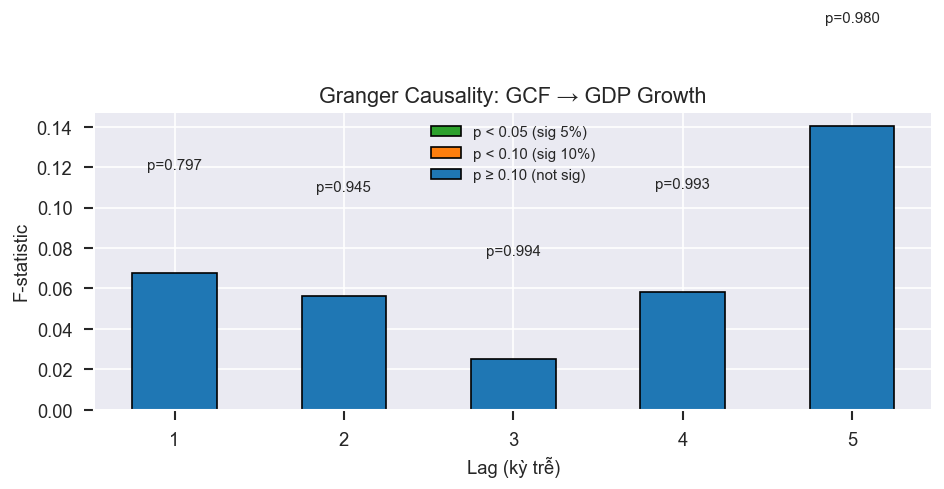


[Lưu biểu đồ] d:\HK2- 2025-2026\DATA Analyst\Đợt 1\lag_analysis_output\04_granger_causality.png


In [ ]:
# PHẦN 3: GRANGER CAUSALITY – ĐẦU TƯ → TĂNG TRƯỞNG GDP
# ====================================================================
print("\n" + "=" * 70)
print("PHẦN 3: KIỂM ĐỊNH GRANGER CAUSALITY")
print("  H0: GCF KHÔNG Granger-cause GDP_growth")
print("=" * 70)

# Chuẩn bị chuỗi: kiểm tra tính dừng
print("\n--- Kiểm định ADF (tính dừng) ---")
for col_name, col_data in [("gcf", df["gcf"]), ("gdp_growth", df["gdp_growth"])]:
    adf_result = adfuller(col_data.dropna(), autolag="AIC")
    stat_label = "DỪNG ✓" if adf_result[1] < 0.05 else "KHÔNG DỪNG ✗"
    print(f"  {col_name:12s}: ADF stat = {adf_result[0]:.4f}, p = {adf_result[1]:.4f}  → {stat_label}")

# Nếu chuỗi không dừng → dùng sai phân
gcf_series = df["gcf"].values
gdp_series = df["gdp_growth"].values

# Kiểm tra tính dừng
adf_gcf = adfuller(gcf_series, autolag="AIC")
adf_gdp = adfuller(gdp_series, autolag="AIC")

use_diff = False
if adf_gcf[1] > 0.05 or adf_gdp[1] > 0.05:
    print("\n  → Ít nhất một chuỗi không dừng → Sử dụng sai phân bậc 1 cho Granger test")
    gcf_diff = np.diff(gcf_series)
    gdp_diff = np.diff(gdp_series)
    use_diff = True
    # Kiểm tra lại
    adf_gcf_d = adfuller(gcf_diff, autolag="AIC")
    adf_gdp_d = adfuller(gdp_diff, autolag="AIC")
    print(f"  Δgcf       : ADF stat = {adf_gcf_d[0]:.4f}, p = {adf_gcf_d[1]:.4f}")
    print(f"  Δgdp_growth: ADF stat = {adf_gdp_d[0]:.4f}, p = {adf_gdp_d[1]:.4f}")
else:
    print("\n  → Cả hai chuỗi đều dừng → Dùng chuỗi gốc cho Granger test")

# Tạo dữ liệu cho Granger test
if use_diff:
    granger_data = np.column_stack([gdp_diff, gcf_diff])  # [y, x] – y là biến phụ thuộc
else:
    granger_data = np.column_stack([gdp_series, gcf_series])

print(f"\n--- Granger Causality Test (max lag = {MAX_LAG}) ---")
print(f"  Dữ liệu: {'sai phân bậc 1' if use_diff else 'chuỗi gốc'}, n = {len(granger_data)}")

granger_results = []
try:
    gc = grangercausalitytests(granger_data, maxlag=MAX_LAG, verbose=False)
    for lag in range(1, MAX_LAG + 1):
        test_stats = gc[lag][0]
        # Lấy F-test (ssr_ftest)
        f_stat = test_stats["ssr_ftest"][0]
        f_pval = test_stats["ssr_ftest"][1]
        # Lấy chi2 test
        chi2_stat = test_stats["ssr_chi2test"][0]
        chi2_pval = test_stats["ssr_chi2test"][1]

        granger_results.append({
            "lag": lag,
            "F_stat": f_stat,
            "F_p_value": f_pval,
            "Chi2_stat": chi2_stat,
            "Chi2_p_value": chi2_pval,
            "sig_5%": "✓" if f_pval < 0.05 else "",
            "sig_10%": "✓" if f_pval < 0.10 else "",
        })
except Exception as e:
    print(f"  [LỖI] Granger test thất bại: {e}")

if granger_results:
    gc_df = pd.DataFrame(granger_results)
    print("\n>>> Bảng kết quả Granger Causality (GCF → GDP_growth)")
    print(gc_df.to_string(index=False, float_format="%.4f"))

    # Tìm lag có p-value nhỏ nhất
    best_gc = gc_df.loc[gc_df["F_p_value"].idxmin()]
    print(f"\n→ Lag có Granger causality mạnh nhất: lag = {int(best_gc['lag'])}")
    print(f"  F = {best_gc['F_stat']:.4f}, p = {best_gc['F_p_value']:.4f}")
    if best_gc['F_p_value'] < 0.05:
        print("  → Có ý nghĩa thống kê ở mức 5%: BÁC BỎ H0 → GCF Granger-cause GDP_growth")
    elif best_gc['F_p_value'] < 0.10:
        print("  → Có ý nghĩa thống kê ở mức 10%: BÁC BỎ H0 → GCF Granger-cause GDP_growth")
    else:
        print("  → KHÔNG có ý nghĩa thống kê → KHÔNG BÁC BỎ H0")

    # --- Biểu đồ Granger p-values ---
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors_gc = ['#2ca02c' if p < 0.05 else ('#ff7f0e' if p < 0.10 else '#1f77b4')
                 for p in gc_df["F_p_value"]]
    ax.bar(gc_df["lag"], gc_df["F_stat"], color=colors_gc, edgecolor="black", width=0.5)
    ax.set_xlabel("Lag (kỳ trễ)")
    ax.set_ylabel("F-statistic")
    ax.set_title("Granger Causality: GCF → GDP Growth")
    ax.set_xticks(range(1, MAX_LAG + 1))

    # Thêm p-value trên mỗi cột
    for _, row in gc_df.iterrows():
        ax.text(row["lag"], row["F_stat"] + 0.05, f'p={row["F_p_value"]:.3f}',
                ha="center", va="bottom", fontsize=9)

    ax.axhline(0, color="black", linewidth=0.5)
    legend_elements_gc = [
        Patch(facecolor='#2ca02c', edgecolor='black', label='p < 0.05 (sig 5%)'),
        Patch(facecolor='#ff7f0e', edgecolor='black', label='p < 0.10 (sig 10%)'),
        Patch(facecolor='#1f77b4', edgecolor='black', label='p ≥ 0.10 (not sig)'),
    ]
    ax.legend(handles=legend_elements_gc, loc="best", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "04_granger_causality.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n[Lưu biểu đồ] {OUTPUT_DIR / '04_granger_causality.png'}")

# ====================================================================


### Tổng hợp kết luận lag analysis


In [ ]:
# TỔNG HỢP KẾT LUẬN
# ====================================================================
print("\n" + "=" * 70)
print("TỔNG HỢP KẾT LUẬN")
print("=" * 70)

print(f"""
1. CROSS-CORRELATION (Investment(t-k) vs ΔGDP(t)):
   → Lag k={int(best_cc['lag_k'])} cho hệ số tương quan cao nhất
     (r = {best_cc['pearson_r']:.4f}, p = {best_cc['p_value']:.4f})

2. ICOR theo Lag:
   → Lag k={int(best_icor_lag['lag_k'])} cho ICOR ổn định & hợp lý nhất
     (Mean = {best_icor_lag['mean']:.2f}, CV = {best_icor_lag['CV%']:.1f}%,
      {best_icor_lag['%_in_3-6']:.1f}% nằm trong khoảng [3–6])
""")

if granger_results:
    print(f"""3. GRANGER CAUSALITY (GCF → GDP_growth):
   → Lag = {int(best_gc['lag'])} có Granger causality mạnh nhất
     (F = {best_gc['F_stat']:.4f}, p = {best_gc['F_p_value']:.4f})
""")

print("Giải thích kinh tế:")
print("  - Với nước đang phát triển như Việt Nam, ICOR hợp lý thường rơi")
print("    vào khoảng 3–6. Lag k phù hợp giúp phản ánh đúng thời gian")
print("    để đầu tư phát huy hiệu quả vào tăng trưởng GDP.")
print("  - Lag càng lớn → đầu tư cần thời gian dài hơn để tác động.")
print("  - Lag k=0 giả định đầu tư tác động ngay lập tức (ít thực tế).")
print("  - Lag k=1-2 thường hợp lý cho Việt Nam (giai đoạn xây dựng,")
print("    triển khai dự án mất 1–2 năm).")

print("\n" + "=" * 70)
print("PHÂN TÍCH HOÀN TẤT. Kết quả lưu tại:", OUTPUT_DIR)
print("=" * 70)



TỔNG HỢP KẾT LUẬN

1. CROSS-CORRELATION (Investment(t-k) vs ΔGDP(t)):
   → Lag k=1 cho hệ số tương quan cao nhất
     (r = -0.0594, p = 0.7428)

2. ICOR theo Lag:
   → Lag k=0 cho ICOR ổn định & hợp lý nhất
     (Mean = 5.14, CV = 38.6%,
      82.9% nằm trong khoảng [3–6])

3. GRANGER CAUSALITY (GCF → GDP_growth):
   → Lag = 1 có Granger causality mạnh nhất
     (F = 0.0675, p = 0.7968)

Giải thích kinh tế:
  - Với nước đang phát triển như Việt Nam, ICOR hợp lý thường rơi
    vào khoảng 3–6. Lag k phù hợp giúp phản ánh đúng thời gian
    để đầu tư phát huy hiệu quả vào tăng trưởng GDP.
  - Lag càng lớn → đầu tư cần thời gian dài hơn để tác động.
  - Lag k=0 giả định đầu tư tác động ngay lập tức (ít thực tế).
  - Lag k=1-2 thường hợp lý cho Việt Nam (giai đoạn xây dựng,
    triển khai dự án mất 1–2 năm).

PHÂN TÍCH HOÀN TẤT. Kết quả lưu tại: d:\HK2- 2025-2026\DATA Analyst\Đợt 1\lag_analysis_output


## 13. Kết luận ngắn

- Dữ liệu Việt Nam sau xử lý có 35 quan sát, giai đoạn 1990-2024.
- ICOR trung bình toàn kỳ khoảng 5.14; các năm bất thường chính là 2020-2021 do cú sốc tăng trưởng GDP.
- Chow Test cho thấy có bằng chứng thay đổi cấu trúc tại 2008 và 2020.
- ARIMAX dùng chuỗi ICOR gốc, không smoothing; mô hình chọn theo AIC là ARIMAX(2, 0, 2) với `macro_shock`.
- Dự báo cơ sở 2025-2029 đưa ICOR về vùng khoảng 4.3-5.5, nhưng khoảng tin cậy còn rộng nên chỉ nên xem là tham khảo.
